# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information


In [2]:
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [3]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.b Import Packages

In [5]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

---
## A. Project Description


In [7]:
business_objective = """

The goal is to develop a machine learning model that can classify patients into one of five diagnostic
categories based on their personal, lifestyle and clinical data. The five categories are Healthy, Anemia,
Rickets/Osteomalacia, Night Blindness and Scurvy. Each condition is tied to a specific vitamin or mineral
deficiency, meaning a correct diagnosis points to what the patient is lacking nutritionally.

The results of this model can be used by healthcare providers to deliver personalised vitamin intake
plans to their patients. Instead of relying solely on expensive blood tests or specialist consultations,
this model acts as a preliminary screening tool that helps clinicians identify patients at risk earlier
and more efficiently. In a practical setting, a patient fills in their lifestyle and dietary information,
the model predicts their most likely diagnosis, and the care team uses that prediction to recommend a
targeted supplement or dietary adjustment.

The impact of accurate results is significant. A correct prediction means a patient receives the right
nutritional guidance at the right time, which can prevent a deficiency from progressing into a more
serious condition. The impact of incorrect results however is not equal in both directions. A false
negative, where the model predicts Healthy but the patient is actually sick, is the more dangerous outcome
because that patient receives no intervention at all. A false positive, where the model flags a deficiency
that does not exist, results in an unnecessary vitamin plan but causes no direct harm. Given this,
the model needs to be evaluated not just on overall accuracy but on how well it detects each disease
class individually, particularly the rarer ones like Scurvy with only 176 cases and Night Blindness
with 269 cases out of 5800 total patients.

"""

In [8]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_objective', value=business_objective)

---
## B. Dataset Understanding (Global Interpretation)

In [9]:
# DO NOT MODIFY THE CODE IN THIS CELL
try:
  df = pd.read_csv(at.folder_path / "disease.csv")
except Exception as e:
  print(e)

In [10]:
df.shape

(5800, 45)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5800 entries, 0 to 5799
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            5800 non-null   object 
 1   patient_id             5800 non-null   int64  
 2   gender                 5800 non-null   object 
 3   age                    5800 non-null   int64  
 4   birth_country          5800 non-null   object 
 5   full_name              5800 non-null   object 
 6   address                5800 non-null   object 
 7   address_number         5800 non-null   int64  
 8   street_name            5800 non-null   object 
 9   street_suffix          5800 non-null   object 
 10  city                   5800 non-null   object 
 11  postcode               5800 non-null   int64  
 12  state                  5800 non-null   object 
 13  email                  5800 non-null   object 
 14  phone                  5800 non-null   object 
 15  bmi 

In [12]:
df.head()

,customer_id,patient_id,gender,age,birth_country,full_name,address,address_number,street_name,street_suffix,...,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,Peripheral neuropathy,has_memory_problems,has_pale_skin,disease_diagnosis
0,02217bbc-2140-49d5-b902-da4f02773377,0,Male,21,AU,Cory Osborn,Flat 88,4,Sanchez Walk,Sound,...,0,0,0,0,0,0,0,0,0,Healthy
1,f4abfaaf-cfe8-422c-aae6-dc75a0ce5264,1,Female,23,AU,Brittany Nelson,Flat 80,994,Monica Court,Fairway,...,4,0,0,0,1,1,1,1,0,Anemia
2,b89ed01b-64c2-4106-b1c0-a11954886f15,2,Male,75,AU,Randy Alvarez,Suite 201,6,Eric Path,Corner,...,2,0,0,0,0,0,1,1,0,Rickets_Osteomalacia
3,10bea7ab-c328-4368-8ccd-2b3ac2567e4d,3,Male,22,AU,William Bowman,Suite 113,27,Johnson Foreshore,Gates,...,3,0,1,0,1,1,0,0,0,Rickets_Osteomalacia
4,d99b8db5-12b1-4111-b27a-6cc30a686442,4,Female,40,AU,Jennifer Williams,Suite 401,41,Weaver Wynd,Track,...,0,0,0,0,0,0,0,0,0,Healthy


In [13]:
df.tail()

,customer_id,patient_id,gender,age,birth_country,full_name,address,address_number,street_name,street_suffix,...,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,Peripheral neuropathy,has_memory_problems,has_pale_skin,disease_diagnosis
5795,4763c763-a3e6-48f1-95bd-d4c46129d22b,5795,Male,25,AU,Randy Tapia,39/,203,Smith Vale,Glade,...,0,0,0,0,0,0,0,0,0,Healthy
5796,10b18565-1693-4392-b280-7fa65747eb27,5796,Female,66,AU,Erica Lopez,Apt. 337,22,Valenzuela Laneway,Right Of Way,...,2,0,0,1,1,0,0,0,0,Scurvy
5797,ec8c4168-78a8-45e2-ae07-604f4117ade5,5797,Female,40,AU,Bethany Davis,705/,21,Daniels Steps,Courtyard,...,0,0,0,0,0,0,0,0,0,Healthy
5798,c41a5455-1cda-42b2-b7dd-88f812750dd6,5798,Male,83,AU,Isaiah Lindsey,Unit 91,8,Anderson Port,Parklands,...,3,1,1,0,0,0,0,0,1,Anemia
5799,aff49531-2a11-4618-aa2b-c8833b2bd4e0,5799,Male,78,IN,Priyansh Wali,2/,9,April Garden,Mall,...,2,0,0,0,1,0,1,0,0,Rickets_Osteomalacia


In [14]:
df.isnull().sum()

,0
customer_id,0
patient_id,0
gender,0
age,0
birth_country,0
full_name,0
address,0
address_number,0
street_name,0
street_suffix,0


In [15]:
df.describe(include = "all")

,customer_id,patient_id,gender,age,birth_country,full_name,address,address_number,street_name,street_suffix,...,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,Peripheral neuropathy,has_memory_problems,has_pale_skin,disease_diagnosis
count,5800,5800.000000,5800,5800.00000,5800,5800,5800,5800.000000,5800,5800,...,5800.000000,5800.000000,5800.000000,5800.000000,5800.000000,5800.000000,5800.000000,5800.000000,5800.000000,5800
unique,5000,NaN,2,NaN,13,3900,1502,NaN,3926,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,1634d170-2c31-41fe-935c-069b996c7592,NaN,Male,NaN,AU,Robert Smith,Unit 08,NaN,Esparza Crossway,End,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthy
freq,2,NaN,2924,NaN,4435,6,151,NaN,140,151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2121
mean,NaN,2899.500000,NaN,51.23500,NaN,NaN,NaN,177.293448,NaN,NaN,...,1.868276,0.103621,0.270000,0.042069,0.301552,0.263966,0.346379,0.304138,0.164828,NaN
std,NaN,1674.460112,NaN,19.92484,NaN,NaN,NaN,274.943904,NaN,NaN,...,1.806913,0.304794,0.443998,0.200764,0.458971,0.440819,0.475857,0.460081,0.371057,NaN
min,NaN,0.000000,NaN,6.00000,NaN,NaN,NaN,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,1449.750000,NaN,34.00000,NaN,NaN,NaN,6.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,2899.500000,NaN,50.00000,NaN,NaN,NaN,40.000000,NaN,NaN,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,4349.250000,NaN,67.00000,NaN,NaN,NaN,219.000000,NaN,NaN,...,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN


In [16]:
num_cols = [
    'age', 'bmi',
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake',
    'calcium_intake', 'iron_intake',
    'hemoglobin_levels', 'serum_vitamin_d', 'serum_vitamin_b12',
    'serum_folate', 'symptoms_count'
]

df[num_cols].describe().round(2)

,age,bmi,vitamin_a_intake,vitamin_c_intake,vitamin_d_intake,vitamin_e_intake,vitamin_b12_intake,folate_intake,calcium_intake,iron_intake,hemoglobin_levels,serum_vitamin_d,serum_vitamin_b12,serum_folate,symptoms_count
count,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00,5800.00
mean,51.24,26.08,90.78,90.96,73.86,88.67,63.24,89.88,80.59,75.36,13.94,21.21,257.10,10.72,1.87
std,19.92,4.91,39.37,36.51,42.19,38.59,36.52,37.44,37.51,33.09,1.69,13.69,161.47,4.92,1.81
min,6.00,15.00,-5.41,10.00,-24.24,-15.32,-0.37,3.44,-20.59,-1.41,8.20,-20.41,-201.25,-0.18,0.00
25%,34.00,22.80,60.88,63.50,42.93,59.38,34.20,62.50,53.70,50.78,12.90,11.70,121.98,7.01,0.00
50%,50.00,26.10,86.30,87.30,65.71,82.80,56.05,85.00,76.40,70.60,13.90,18.80,223.82,9.66,2.00
75%,67.00,29.40,120.12,114.40,97.50,113.20,87.10,114.20,104.93,94.20,15.02,27.94,345.10,13.70,3.00
max,107.00,45.00,219.00,250.00,275.60,237.60,243.60,226.60,232.70,211.40,18.00,80.00,1138.10,25.00,9.00


In [17]:
df["smoking_status"].value_counts(dropna = False)

,count
smoking_status,
Former,1892
Current,1858
Never,1845
NaN,169
Unknown,36


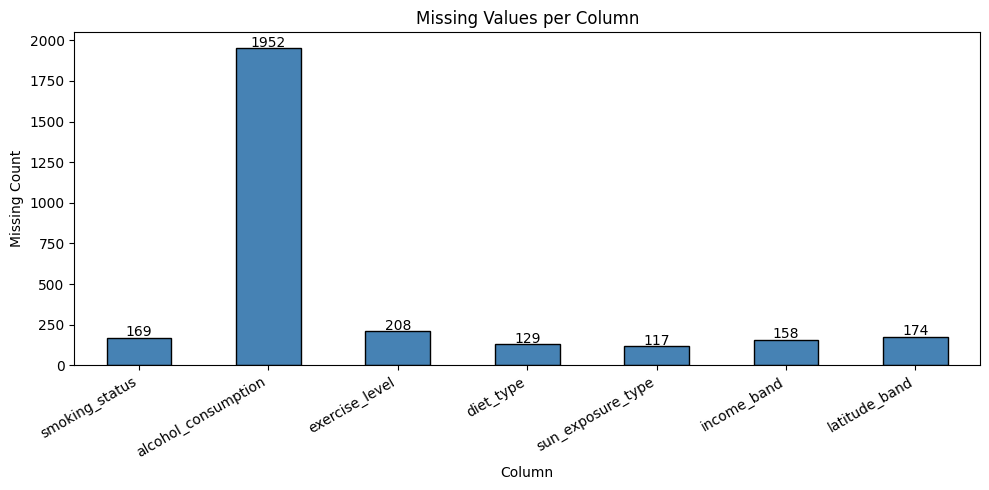

In [18]:
# missing values bar chart
missing = df.isnull().sum()
missing = missing[missing > 0]  # only columns that have missing values

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Missing Values per Column')
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=30, ha='right')

# adds count labels on top of each bar
for i, val in enumerate(missing):
    plt.text(i, val + 10, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

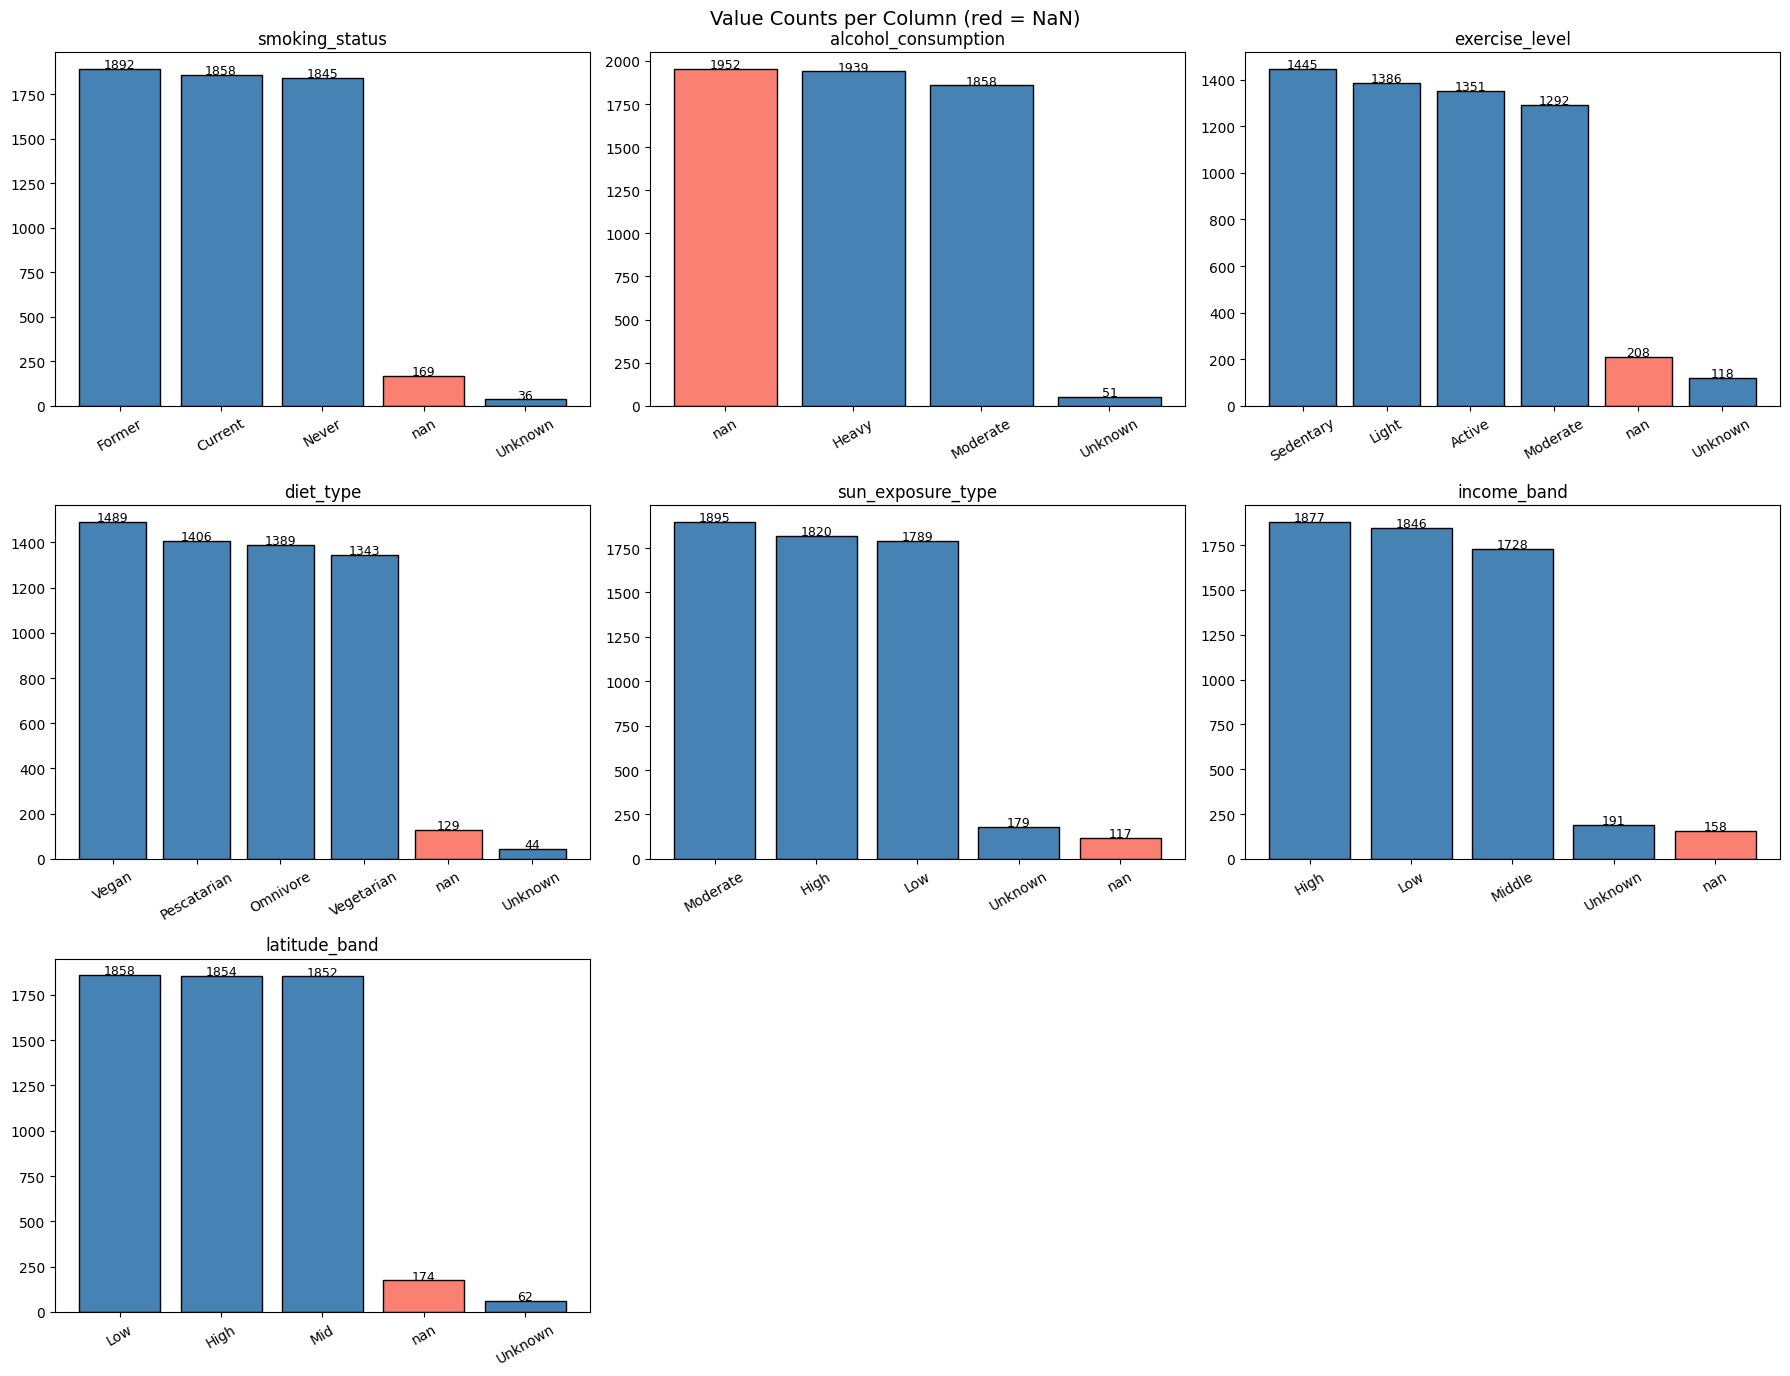

In [19]:
# plot value counts for all 7 columns with missing values
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

cols_with_missing = ['smoking_status', 'alcohol_consumption', 'exercise_level',
                     'diet_type', 'sun_exposure_type', 'income_band', 'latitude_band']

for i, col in enumerate(cols_with_missing):
    counts = df[col].value_counts(dropna=False)
    colors = ['salmon' if str(x) == 'nan' else 'steelblue' for x in counts.index]
    axes[i].bar(counts.index.astype(str), counts.values, color=colors, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for j, val in enumerate(counts.values):
        axes[i].text(j, val + 5, str(val), ha='center', fontsize=9)

# hide the 2 empty subplots since we only have 7 columns
axes[7].set_visible(False)
axes[8].set_visible(False)

fig.suptitle('Value Counts per Column (red = NaN)', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
df.duplicated().sum()

np.int64(0)

---
## C. Feature Understanding (Local Interpretation)

### C.1 Explore Target Variable

> Save the name of column used as the target variable and call it `target_name`

> You can add more cells in this section

In [21]:
target_name = 'disease_diagnosis'

In [22]:
print("Missing values in target:", df['disease_diagnosis'].isna().sum())
print()
print("Unique classes:")
print(df['disease_diagnosis'].unique())
print()
print("Value counts:")
print(df['disease_diagnosis'].value_counts())

Missing values in target: 0

Unique classes:
['Healthy' 'Anemia' 'Rickets_Osteomalacia' 'Scurvy' 'Night_Blindness']

Value counts:
disease_diagnosis
Healthy                 2121
Anemia                  1805
Rickets_Osteomalacia    1429
Night_Blindness          269
Scurvy                   176
Name: count, dtype: int64


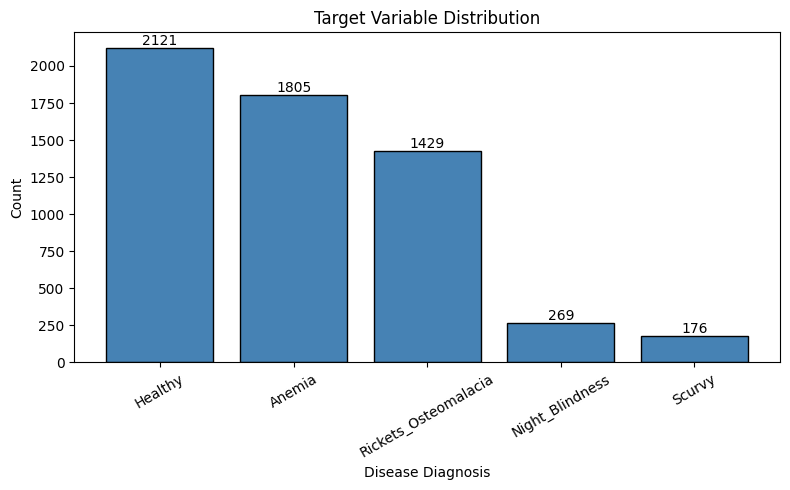

In [23]:
counts = df['disease_diagnosis'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
plt.title('Target Variable Distribution')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=30)
for i, val in enumerate(counts.values):
    plt.text(i, val + 20, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

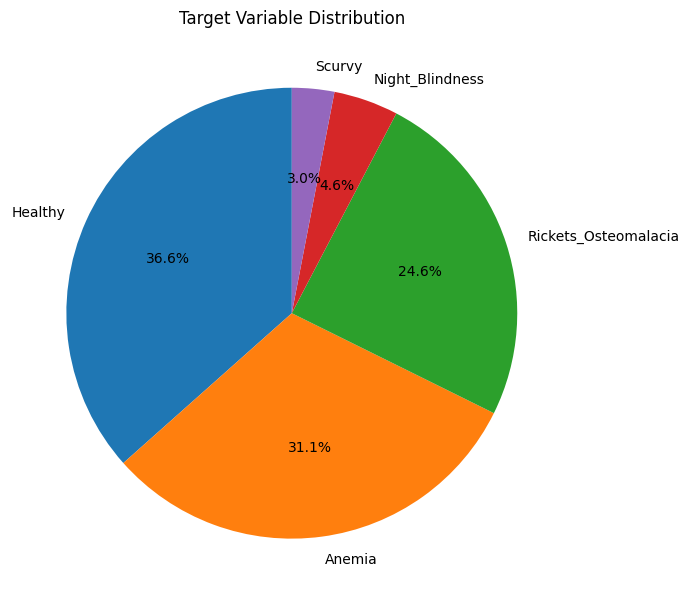

In [24]:
plt.figure(figsize=(7, 7))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Target Variable Distribution')
plt.tight_layout()
plt.show()

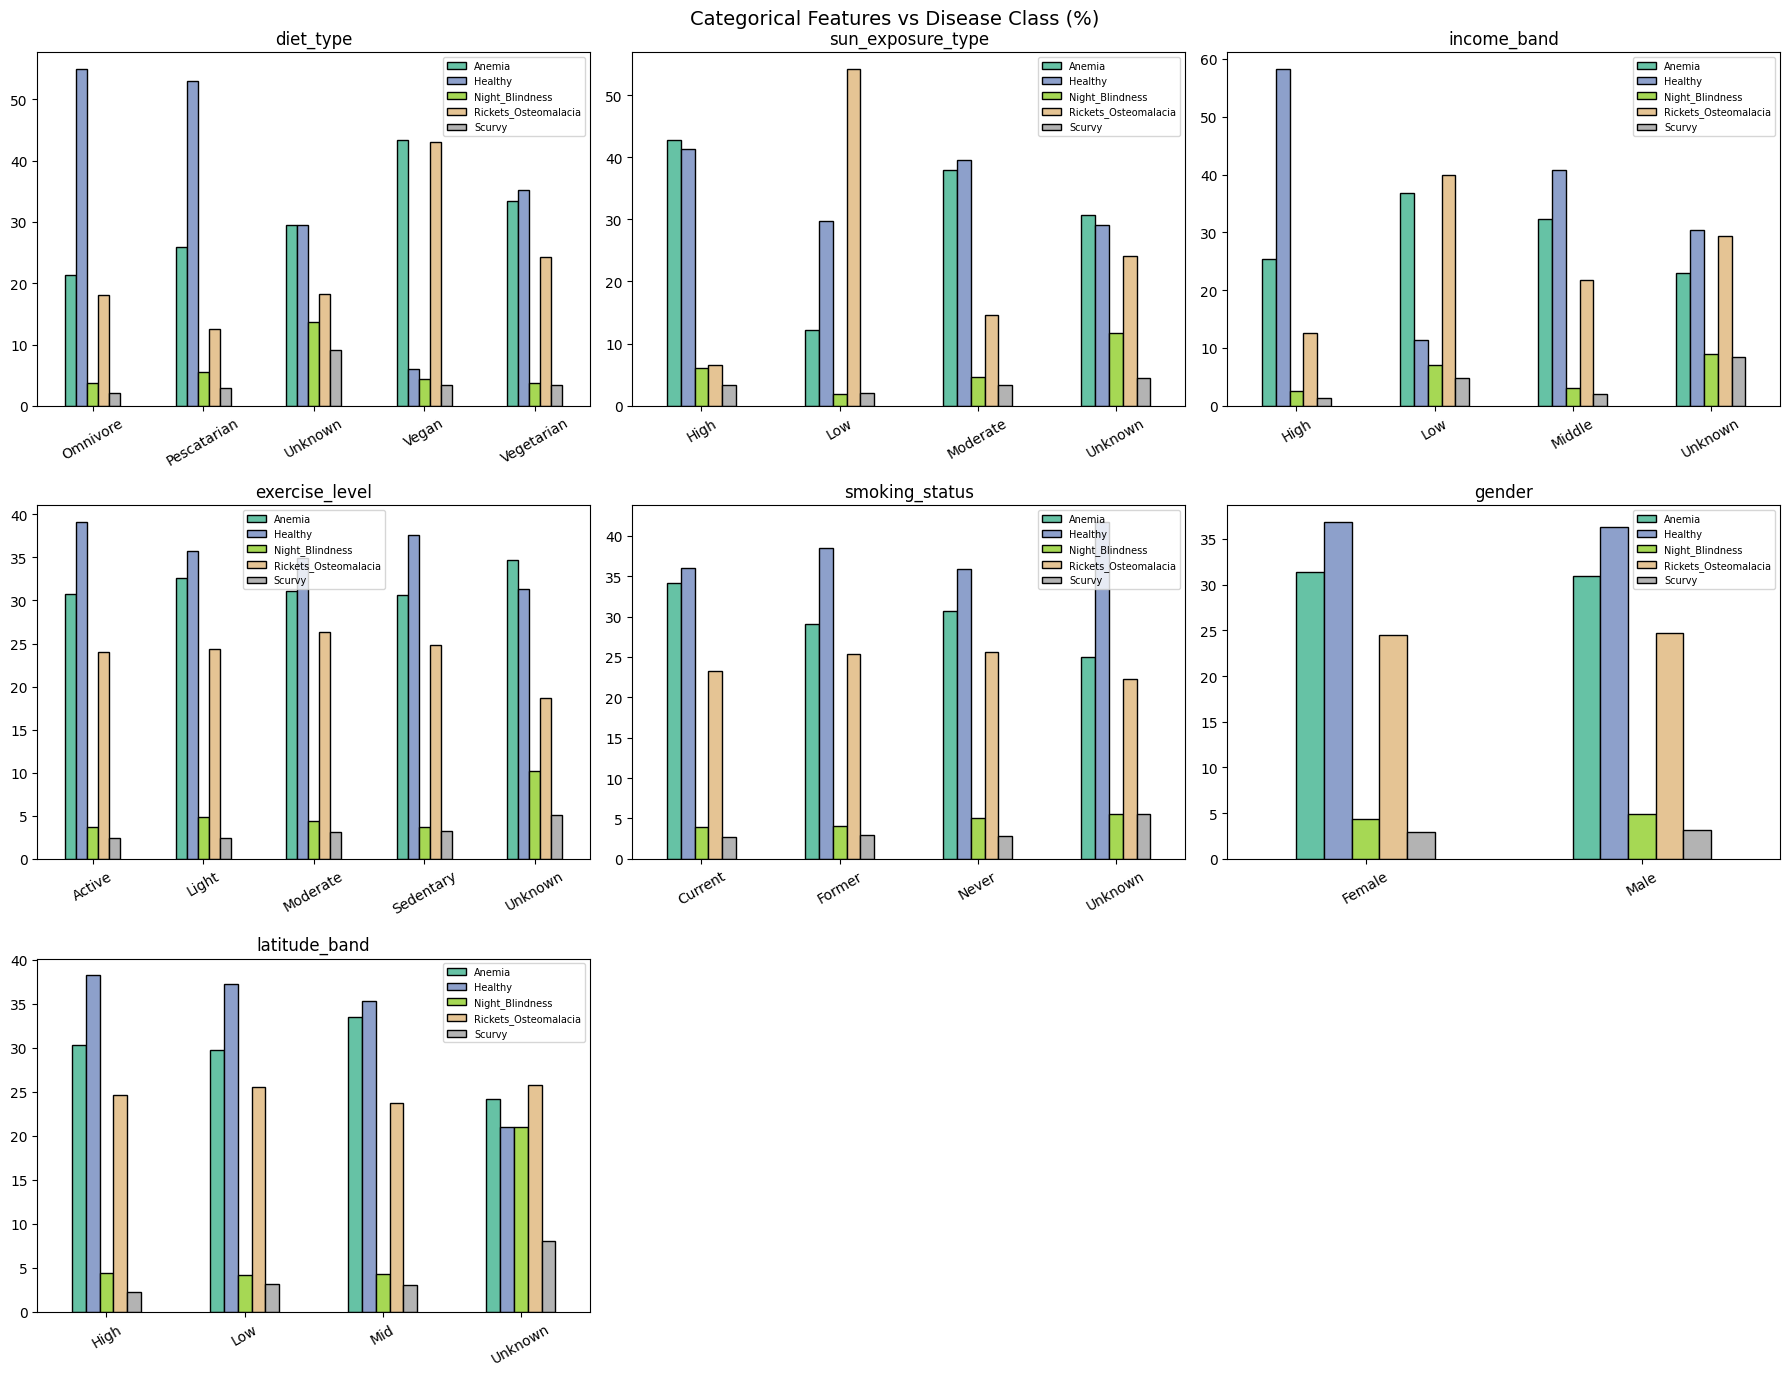

In [25]:
# crosstab for categorical features vs target
cat_cols = ['diet_type', 'sun_exposure_type', 'income_band',
            'exercise_level', 'smoking_status', 'gender', 'latitude_band']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    crosstab = pd.crosstab(df[col], df['disease_diagnosis'], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7)

axes[7].set_visible(False)
axes[8].set_visible(False)

fig.suptitle('Categorical Features vs Disease Class (%)', fontsize=14)
plt.tight_layout()
plt.show()

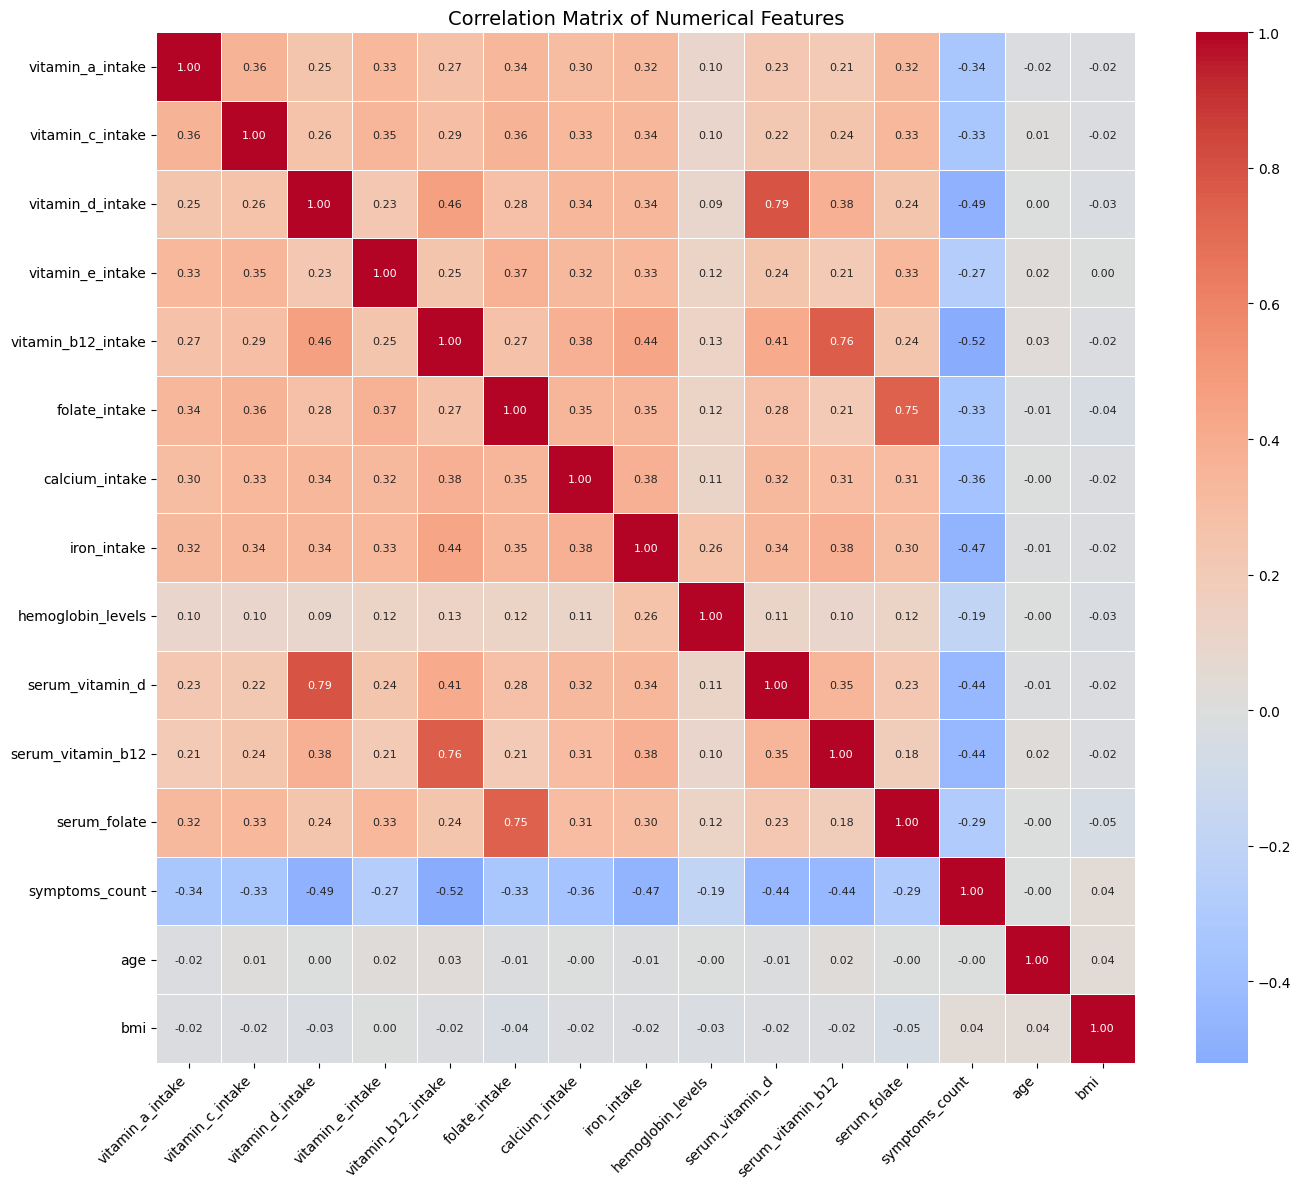

In [26]:
#Correlation Matrix of Numerical Features
num_cols = [
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake',
    'calcium_intake', 'iron_intake', 'hemoglobin_levels',
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'symptoms_count', 'age', 'bmi'
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    df[num_cols].corr().round(2),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


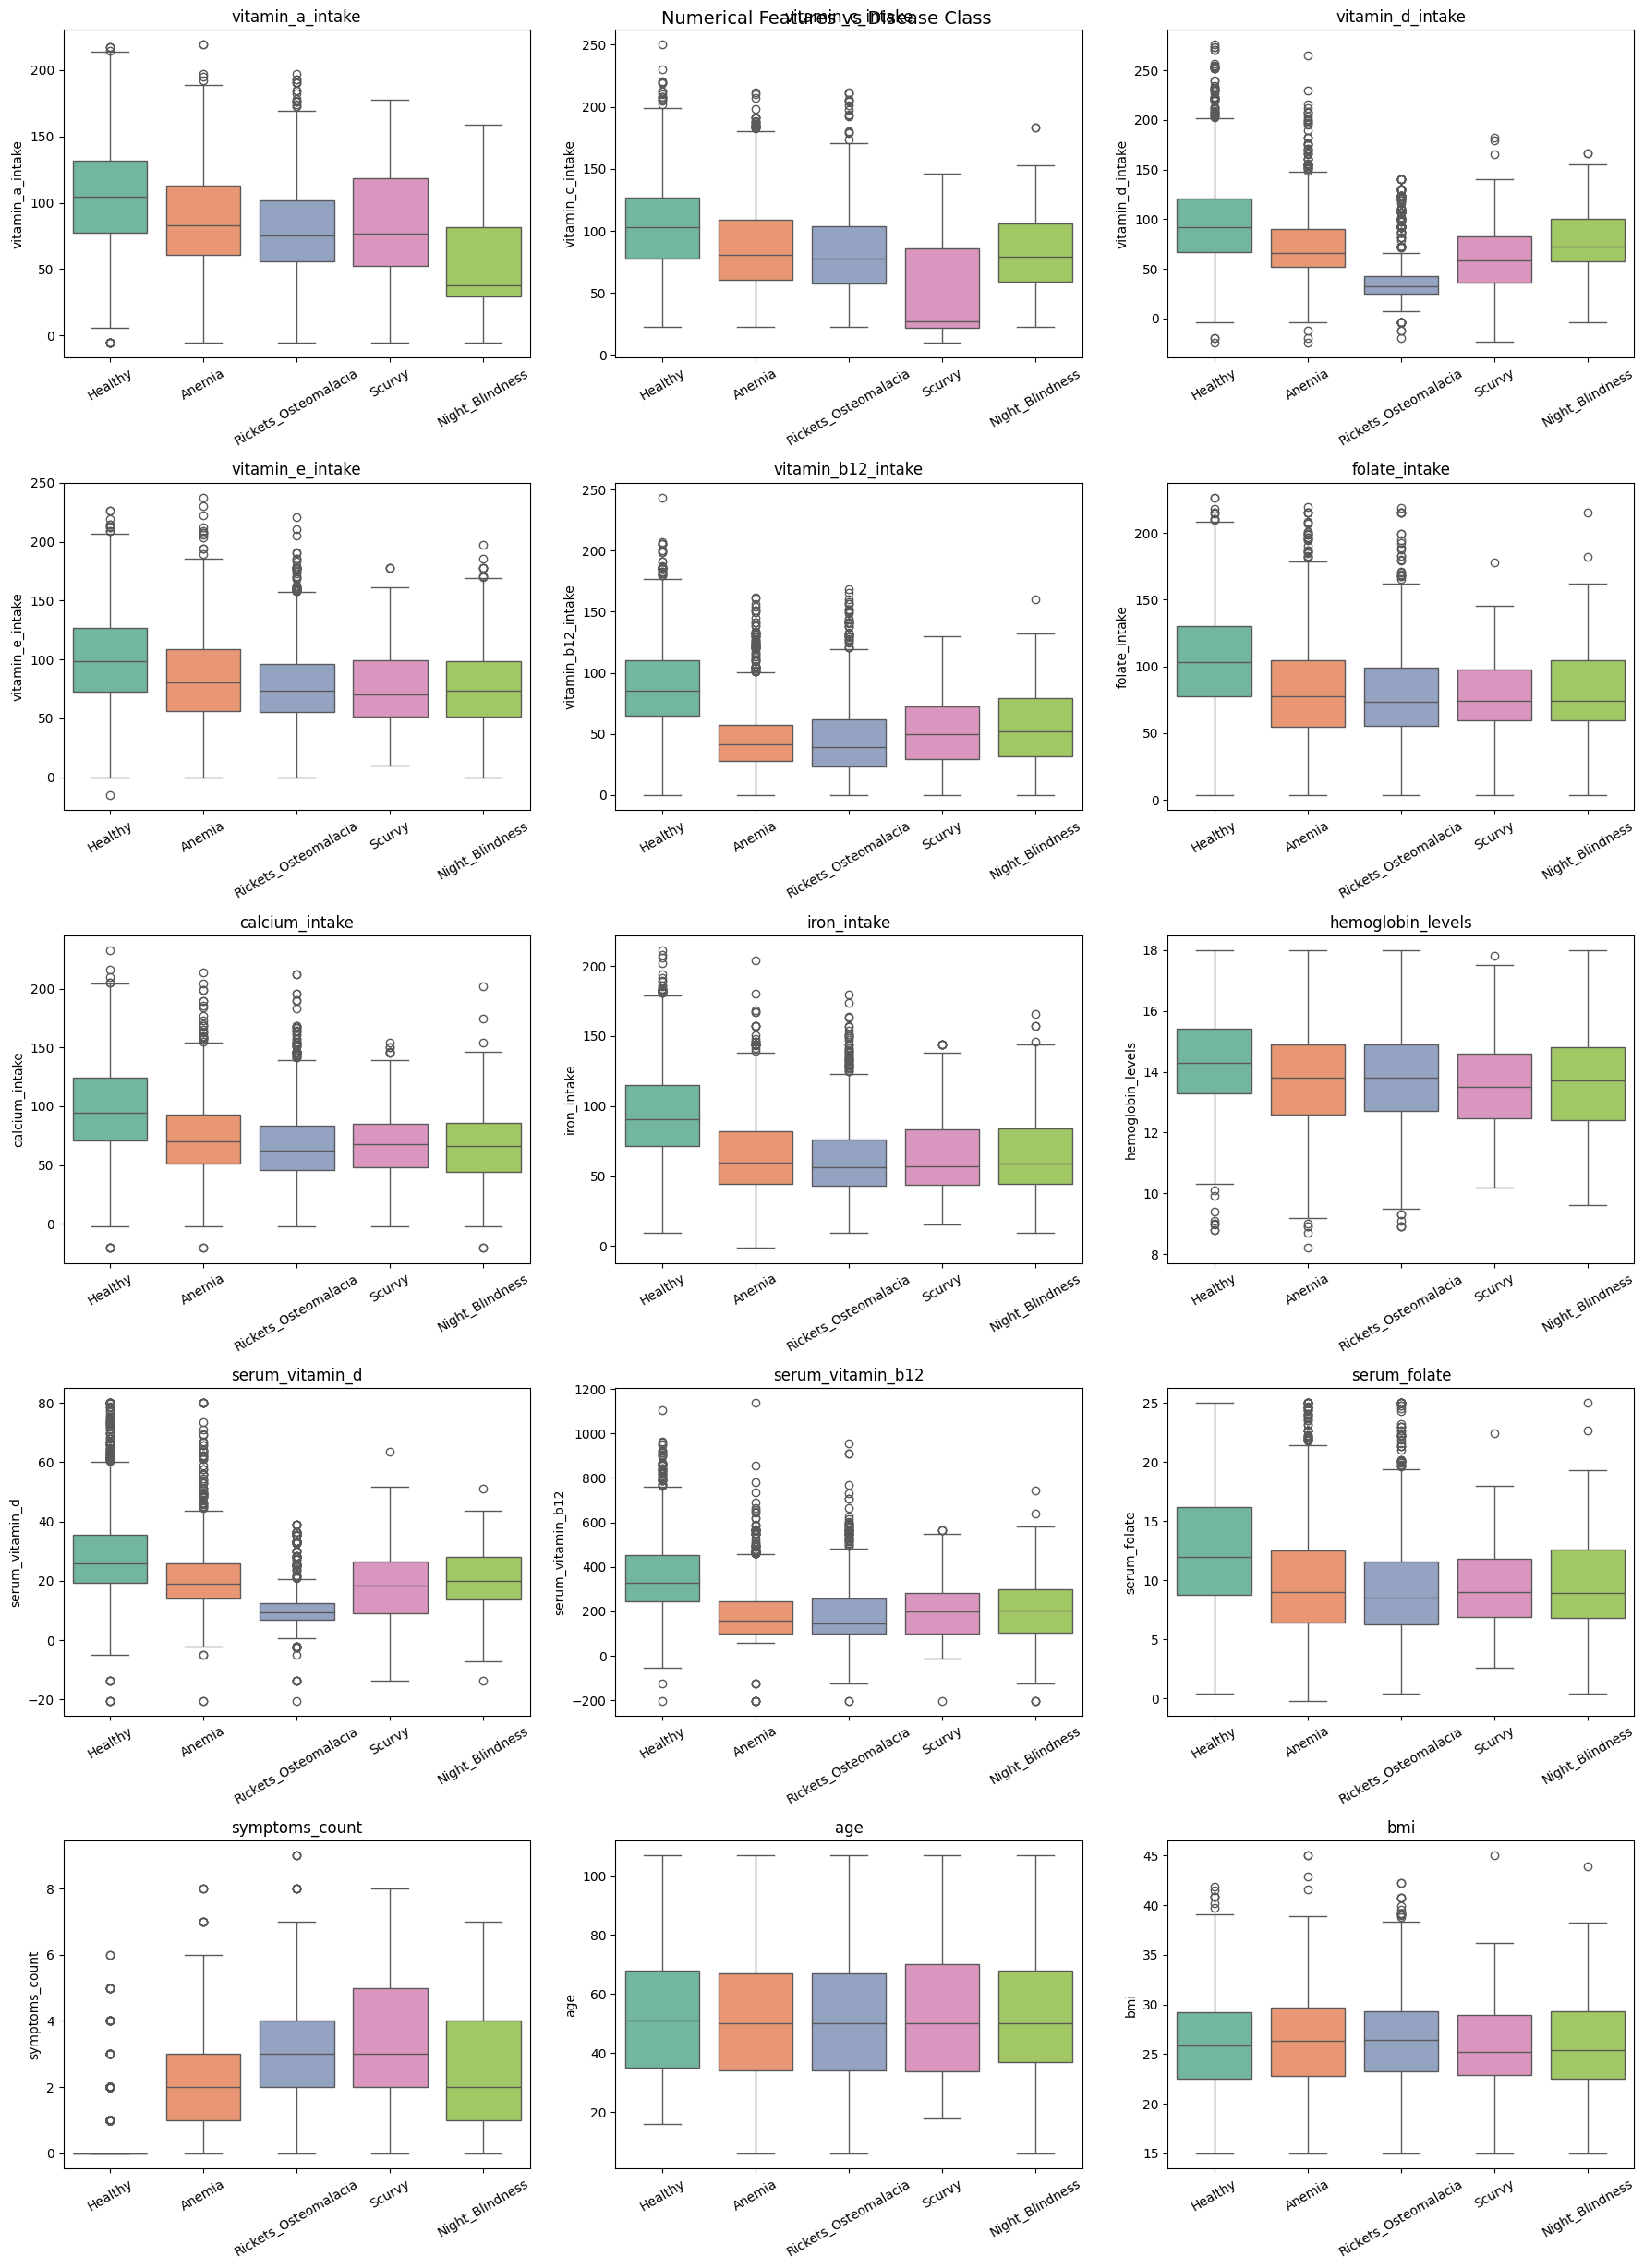

In [27]:
# boxplots for numerical features vs target
fig, axes = plt.subplots(5, 3, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='disease_diagnosis', y=col,
                ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Numerical Features vs Disease Class', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
# symptom columns vs disease class
symptom_cols = [
    'has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
    'has_bone_pain', 'has_muscle_weakness', 'Peripheral neuropathy',
    'has_memory_problems', 'has_pale_skin'
]

symptom_means = df.groupby('disease_diagnosis')[symptom_cols].mean().round(2)
print(symptom_means)

                      has_night_blindness  has_fatigue  has_bleeding_gums  \
disease_diagnosis                                                           
Anemia                               0.08         0.42               0.04   
Healthy                              0.03         0.02               0.01   
Night_Blindness                      0.52         0.32               0.02   
Rickets_Osteomalacia                 0.15         0.39               0.04   
Scurvy                               0.17         0.67               0.54   

                      has_bone_pain  has_muscle_weakness  \
disease_diagnosis                                          
Anemia                         0.22                 0.18   
Healthy                        0.13                 0.11   
Night_Blindness                0.18                 0.20   
Rickets_Osteomalacia           0.67                 0.61   
Scurvy                         0.36                 0.27   

                      Peripheral neurop

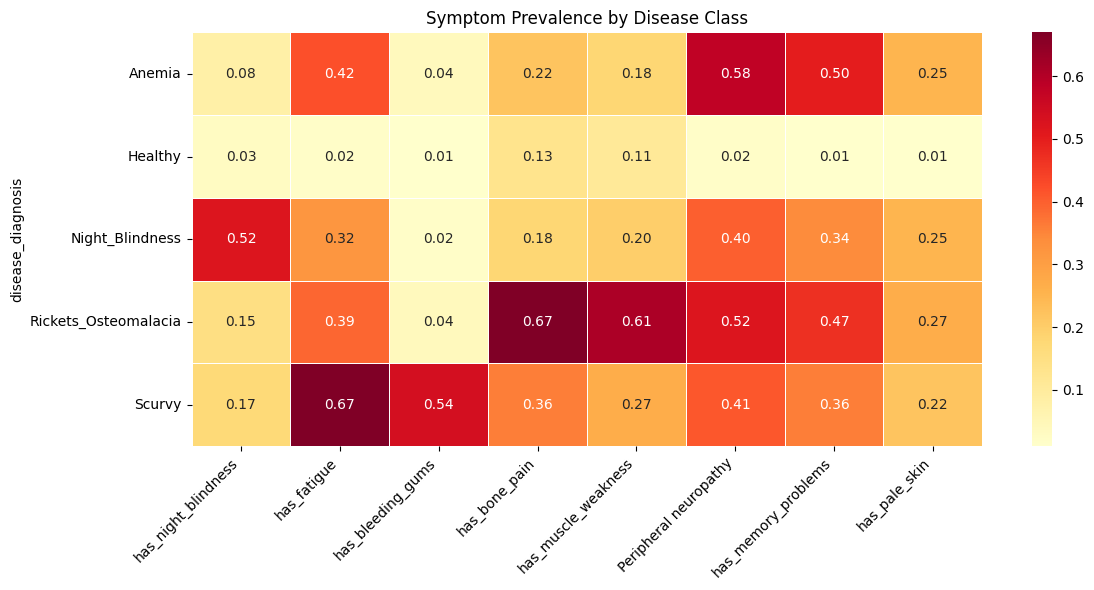

In [29]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.groupby('disease_diagnosis')[symptom_cols].mean().round(2),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Symptom Prevalence by Disease Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
target_insights = """

The target variable disease_diagnosis has 5 classes: Healthy, Anemia, Rickets_Osteomalacia, Night_Blindness
and Scurvy. There are no missing values in the target column and all class names are clean and consistent.

The dataset has a significant class imbalance. Healthy is the largest class with 2121 patients (36.6%)
and Scurvy is the smallest with only 176 patients (3.0%). The imbalance ratio between the largest and
smallest class is 12.1x. Anemia has 1805 patients (31.1%), Rickets_Osteomalacia has 1429 (24.6%) and
Night_Blindness has 269 patients (4.6%). This imbalance needs to be accounted for during modelling as
overall accuracy alone will not be a reliable metric.

From the boxplots, several numerical features show clear separation between disease classes.
serum_vitamin_d is noticeably lower for Rickets_Osteomalacia patients compared to all other classes.
vitamin_c_intake is clearly lower for Scurvy patients and vitamin_b12_intake is lower for both Anemia
and Rickets_Osteomalacia. age and bmi show almost no separation across classes meaning they are unlikely
to be useful features for the model.

From the categorical crosstabs, diet_type shows strong separation where Vegan patients have much higher
rates of Anemia and Rickets_Osteomalacia compared to Omnivore patients who are predominantly Healthy.
sun_exposure_type shows that patients with low sun exposure have a much higher proportion of
Rickets_Osteomalacia. income_band also shows a clear pattern where high income patients are mostly
Healthy and low income patients have higher disease rates. exercise_level, smoking_status and gender
show very little separation across disease classes and are unlikely to contribute meaningfully to the
model.

The symptom heatmap confirms strong clinical relationships between symptoms and diagnoses. has_bleeding_gums
is present in 54% of Scurvy patients, has_bone_pain in 67% of Rickets_Osteomalacia patients and
has_night_blindness in 52% of Night_Blindness patients. Healthy patients have near zero prevalence
across all symptoms. These binary symptom columns are expected to be among the strongest predictors
in the model.

The correlation matrix shows that vitamin intake and serum levels are strongly correlated with each
other, for example vitamin_d_intake and serum_vitamin_d at 0.79 and vitamin_b12_intake and serum_vitamin_b12
at 0.76. symptoms_count is negatively correlated with most vitamin intake features which makes clinical
sense as lower vitamin intake leads to more symptoms.

"""

In [31]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='target_insights', value=target_insights)

### C.2 Explore Feature of Interest `serum_vitamin_d`


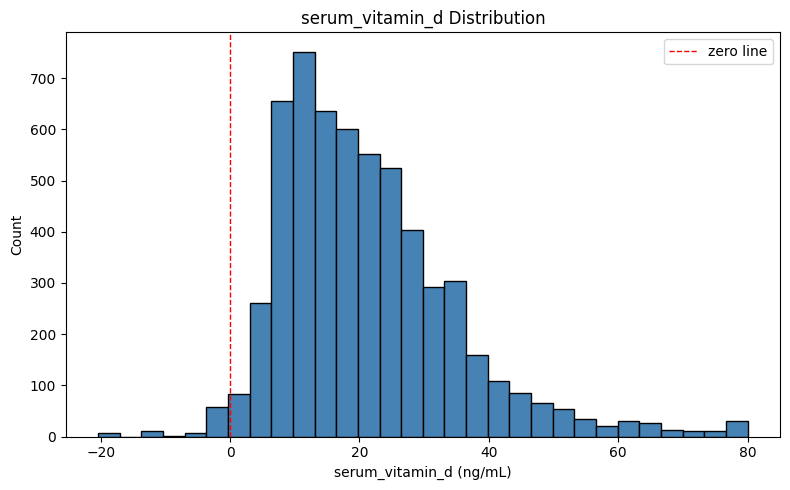

In [32]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['serum_vitamin_d'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('serum_vitamin_d Distribution')
plt.xlabel('serum_vitamin_d (ng/mL)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

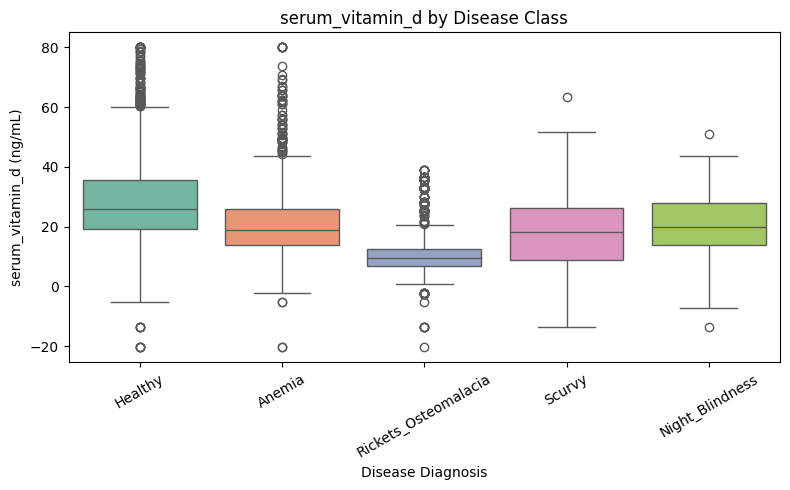

In [33]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='serum_vitamin_d', palette='Set2')
plt.title('serum_vitamin_d by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('serum_vitamin_d (ng/mL)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [34]:
# mean per class
print(df.groupby('disease_diagnosis')['serum_vitamin_d'].describe().round(2))

                       count   mean    std    min    25%    50%    75%    max
disease_diagnosis                                                            
Anemia                1805.0  21.18  11.16 -20.41  14.00  19.00  26.00  80.00
Healthy               2121.0  28.60  14.91 -20.41  19.20  25.90  35.64  80.00
Night_Blindness        269.0  20.49  10.32 -13.54  13.70  19.97  27.94  51.10
Rickets_Osteomalacia  1429.0  10.76   6.67 -20.41   6.90   9.40  12.50  38.99
Scurvy                 176.0  18.55  11.83 -13.54   8.97  18.31  26.35  63.40


In [35]:
feature_1_insights = """

serum_vitamin_d measures the concentration of vitamin D in a patient's blood
in ng/mL. According to the data dictionary the valid range is 5 to 80 ng/mL.
85 patients have negative values which are biologically impossible and will be
removed during data preparation.

The boxplot shows a very clear separation between Rickets_Osteomalacia patients
and all other classes. Rickets patients have a median serum_vitamin_d of 9.40
ng/mL compared to 25.90 for Healthy patients. The entire Rickets box sits well
below every other class with very little overlap. This makes serum_vitamin_d
one of the strongest predictors for Rickets_Osteomalacia in the dataset.

The other disease classes, Anemia, Scurvy and Night_Blindness, overlap
considerably with each other and with Healthy, meaning serum_vitamin_d alone
cannot distinguish between all 5 classes. It will however be a very important
feature for any model trying to identify Rickets patients specifically.

Given this strong signal, serum_vitamin_d is selected as a feature for all
modelling experiments.

"""

In [36]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.3 Explore Feature of Interest `serum_vitamin_b12`

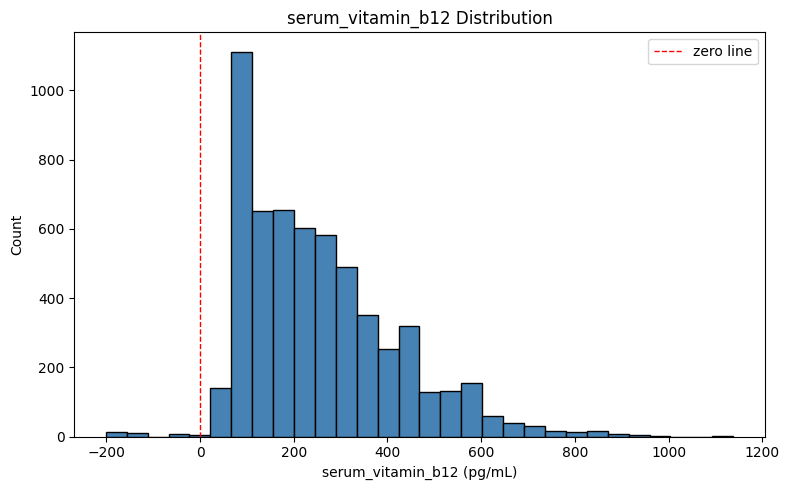

In [37]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['serum_vitamin_b12'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('serum_vitamin_b12 Distribution')
plt.xlabel('serum_vitamin_b12 (pg/mL)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

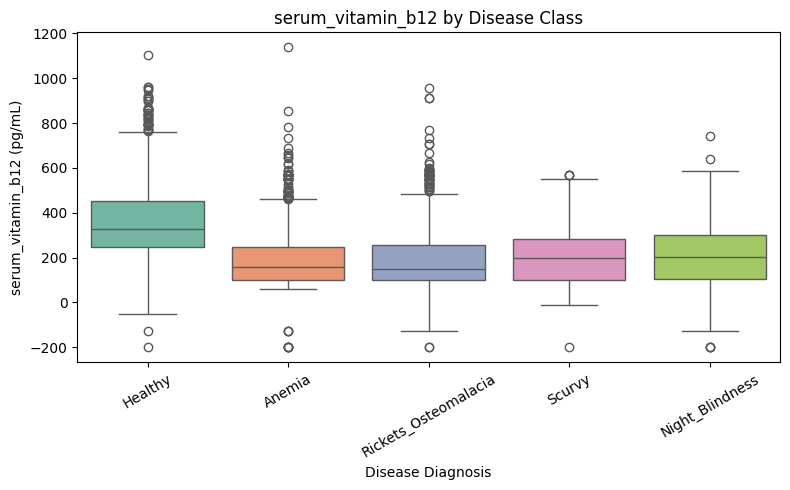

In [38]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='serum_vitamin_b12', palette='Set2')
plt.title('serum_vitamin_b12 by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('serum_vitamin_b12 (pg/mL)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [39]:
# mean per class
print(df.groupby('disease_diagnosis')['serum_vitamin_b12'].describe().round(2))

                       count    mean     std     min     25%     50%     75%  \
disease_diagnosis                                                              
Anemia                1805.0  194.27  121.60 -201.25  100.00  157.60  244.70   
Healthy               2121.0  358.47  162.07 -201.25  246.90  328.70  453.60   
Night_Blindness        269.0  230.09  152.98 -201.25  104.57  204.20  300.24   
Rickets_Osteomalacia  1429.0  195.81  131.25 -201.25  100.00  146.60  257.10   
Scurvy                 176.0  218.89  135.78 -201.25  100.00  198.22  284.38   

                          max  
disease_diagnosis              
Anemia                1138.10  
Healthy               1104.20  
Night_Blindness        743.30  
Rickets_Osteomalacia   957.20  
Scurvy                 567.26  


In [40]:
feature_2_insights = """

serum_vitamin_b12 measures the concentration of vitamin B12 in a patient's
blood in pg/mL. The data dictionary states a valid range of 100 to 1200 pg/mL.
35 patients have negative values which are biologically impossible and will be
removed during data preparation.

The distribution is right skewed with most patients falling between 0 and 400
pg/mL. A small number of patients have very high values above 800 pg/mL which
appear as outliers in the boxplot.

The boxplot shows that Healthy patients have a noticeably higher median of
328.70 pg/mL compared to all disease classes. Anemia patients have the lowest
median at 157.60 pg/mL followed closely by Rickets_Osteomalacia at 146.60
pg/mL. This makes clinical sense as vitamin B12 deficiency is directly linked
to Anemia. Scurvy and Night_Blindness sit in between but all four disease
classes overlap considerably with each other making it difficult to distinguish
between them using this feature alone.

serum_vitamin_b12 is a strong feature for separating Healthy patients from
diseased patients and is selected for all modelling experiments.

"""

In [41]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.4 Explore Feature of Interest `serum_folate`

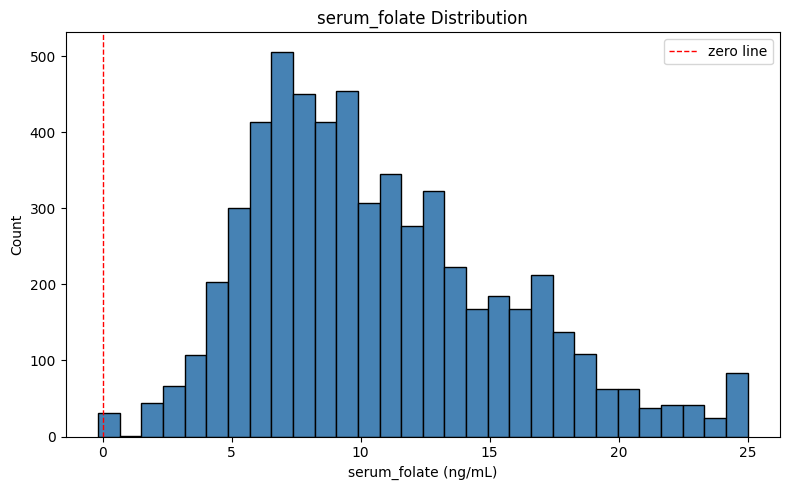

In [42]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['serum_folate'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('serum_folate Distribution')
plt.xlabel('serum_folate (ng/mL)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

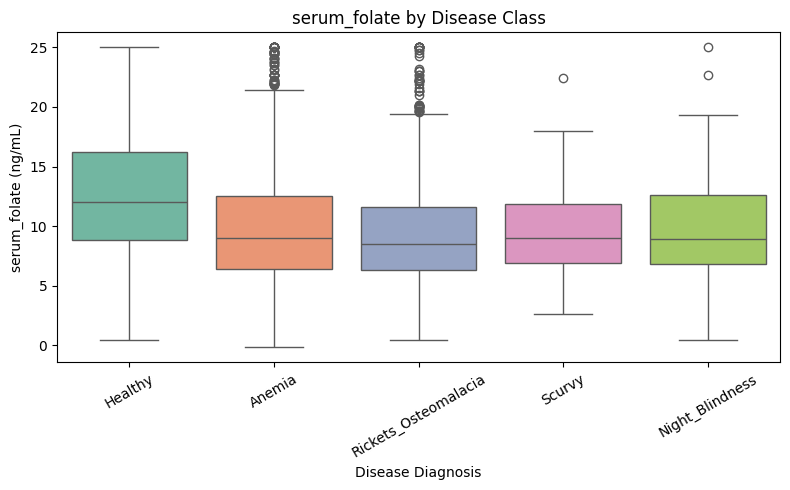

In [43]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='serum_folate', palette='Set2')
plt.title('serum_folate by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('serum_folate (ng/mL)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [44]:
# stats per class
print(df.groupby('disease_diagnosis')['serum_folate'].describe().round(2))

                       count   mean   std   min   25%    50%    75%   max
disease_diagnosis                                                        
Anemia                1805.0   9.87  4.84 -0.18  6.40   9.00  12.50  25.0
Healthy               2121.0  12.58  4.93  0.43  8.80  12.00  16.20  25.0
Night_Blindness        269.0   9.70  4.36  0.43  6.80   8.90  12.60  25.0
Rickets_Osteomalacia  1429.0   9.35  4.37  0.43  6.30   8.50  11.60  25.0
Scurvy                 176.0   9.65  3.79  2.60  6.93   8.97  11.82  22.4


In [45]:
feature_3_insights = """

serum_folate measures the concentration of folate in a patient's blood in
ng/mL. The data dictionary states a valid range of 2 to 25 ng/mL. Only 2
patients have negative values which will be removed during data preparation.

The distribution is roughly bell shaped with most patients falling between 5
and 20 ng/mL. The distribution looks relatively normal compared to the right
skewed distributions seen in serum_vitamin_d and serum_vitamin_b12.

The boxplot shows that Healthy patients have a higher median of 12.00 ng/mL
compared to all disease classes which cluster closely between 8.50 and 9.00.
However the separation is weaker than other serum features as all disease
classes overlap considerably with each other and with Healthy. This means
serum_folate alone cannot reliably distinguish between disease classes but
it still contributes some signal when combined with other features.

serum_folate is selected as a feature for modelling experiments as it adds
complementary information alongside the stronger serum features.

"""

In [46]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.5 Explore Feature of Interest `vitamin_c_intake`

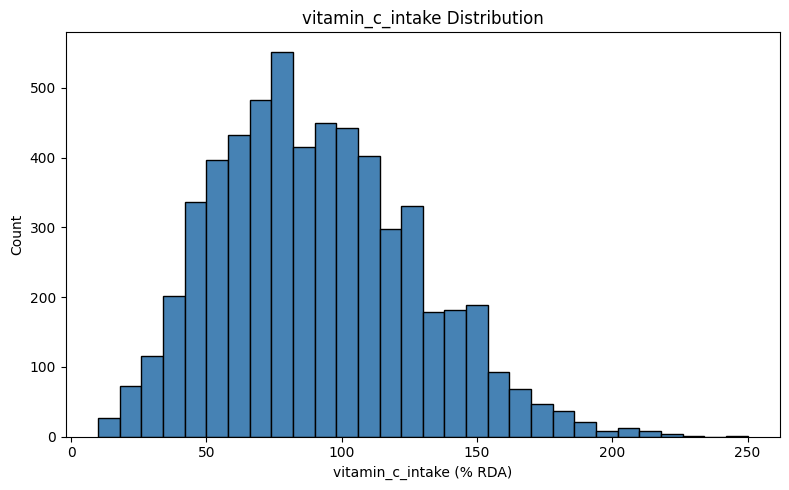

In [47]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['vitamin_c_intake'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('vitamin_c_intake Distribution')
plt.xlabel('vitamin_c_intake (% RDA)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

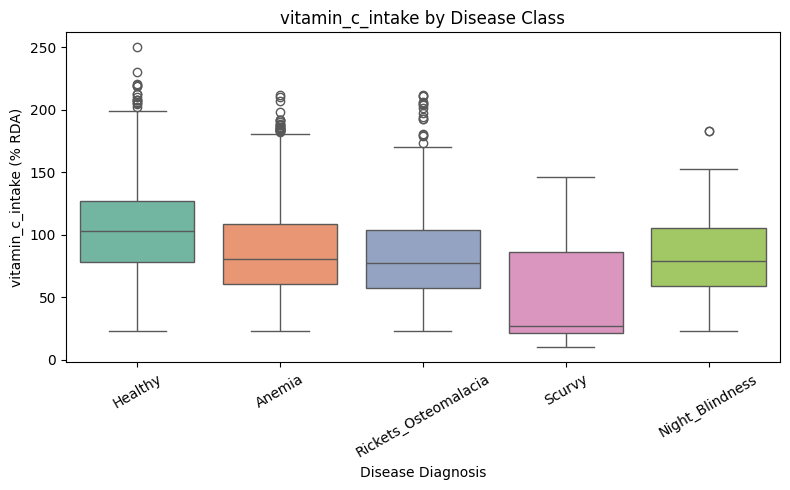

In [48]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='vitamin_c_intake', palette='Set2')
plt.title('vitamin_c_intake by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('vitamin_c_intake (% RDA)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [49]:
# stats per class
print(df.groupby('disease_diagnosis')['vitamin_c_intake'].describe().round(2))

                       count    mean    std    min    25%     50%     75%  \
disease_diagnosis                                                           
Anemia                1805.0   87.00  34.85  22.85  60.90   81.00  109.10   
Healthy               2121.0  103.71  35.31  22.85  78.00  103.40  126.70   
Night_Blindness        269.0   85.04  31.93  22.85  58.80   79.31  105.80   
Rickets_Osteomalacia  1429.0   83.06  33.11  22.85  57.50   77.60  103.60   
Scurvy                 176.0   51.08  41.83  10.00  21.85   27.45   85.92   

                        max  
disease_diagnosis            
Anemia                211.5  
Healthy               250.0  
Night_Blindness       183.4  
Rickets_Osteomalacia  211.5  
Scurvy                146.3  


In [50]:
feature_4_insights = """

vitamin_c_intake measures a patient's vitamin C consumption as a percentage
of the Recommended Dietary Allowance. A value of 100 means the patient meets
the daily recommendation. No negative values exist in this column.

The distribution is roughly bell shaped with most patients consuming between
50 and 150 percent of the RDA. A small number of patients have very high
intakes above 200 percent which appear as outliers.

The boxplot shows a very clear separation for Scurvy patients. The Scurvy
median is only 27.45 percent of RDA compared to 103.40 for Healthy patients.
This makes complete clinical sense as Scurvy is directly caused by severe
vitamin C deficiency. The Scurvy box is also notably wider than other classes
indicating high variability in vitamin C intake among Scurvy patients, with
some consuming almost nothing and others consuming moderate amounts.

Anemia, Rickets_Osteomalacia and Night_Blindness all sit between Scurvy and
Healthy and overlap considerably with each other. This feature is most useful
for identifying Scurvy patients specifically.

vitamin_c_intake is selected as a feature for all modelling experiments due
to its strong signal for Scurvy detection.

"""

In [51]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_3_insights', value=feature_4_insights)

### C.6 Explore Feature of Interest `vitamin_d_intake`

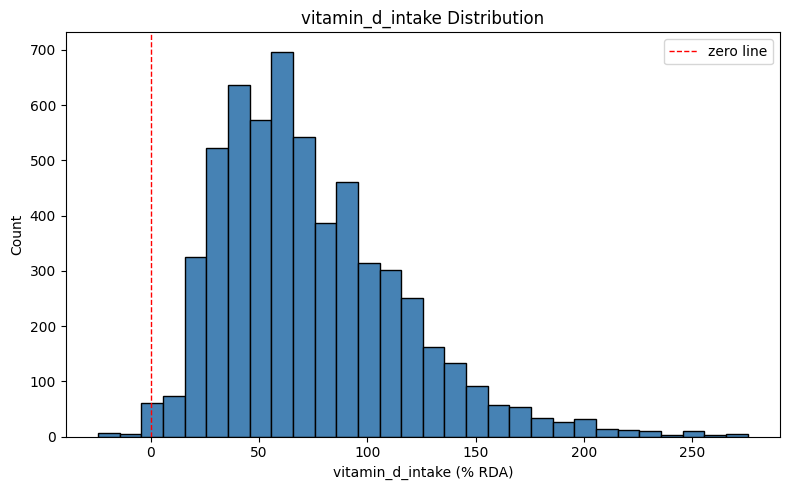

In [52]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['vitamin_d_intake'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('vitamin_d_intake Distribution')
plt.xlabel('vitamin_d_intake (% RDA)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

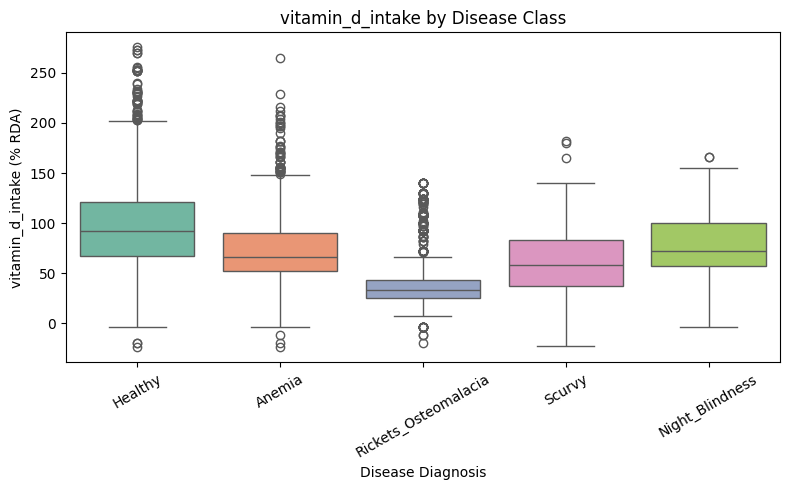

In [53]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='vitamin_d_intake', palette='Set2')
plt.title('vitamin_d_intake by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('vitamin_d_intake (% RDA)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [54]:
# stats per class
print(df.groupby('disease_diagnosis')['vitamin_d_intake'].describe().round(2))

                       count   mean    std    min    25%    50%     75%  \
disease_diagnosis                                                         
Anemia                1805.0  73.13  32.03 -24.24  51.61  65.71   90.48   
Healthy               2121.0  98.54  43.36 -24.24  67.08  91.77  121.10   
Night_Blindness        269.0  78.50  33.02  -3.75  57.47  72.10  100.30   
Rickets_Osteomalacia  1429.0  38.74  24.68 -19.82  25.27  32.76   42.98   
Scurvy                 176.0  62.13  36.91 -23.01  36.64  58.22   82.64   

                         max  
disease_diagnosis             
Anemia                265.07  
Healthy               275.60  
Night_Blindness       166.40  
Rickets_Osteomalacia  140.13  
Scurvy                182.00  


In [55]:
feature_5_insights = """

vitamin_d_intake measures a patient's vitamin D consumption as a percentage
of the Recommended Dietary Allowance. 72 patients have negative values which
are biologically impossible and will be removed during data preparation.

The distribution is right skewed with most patients consuming between 20 and
120 percent of the RDA. A small number of patients have very high intakes
above 200 percent which appear as outliers.

The boxplot shows a very clear separation for Rickets_Osteomalacia patients.
The Rickets median is only 32.76 percent of RDA compared to 91.77 for Healthy
patients. This is consistent with the strong correlation of 0.79 between
vitamin_d_intake and serum_vitamin_d observed in the correlation matrix. Both
features tell the same clinical story, patients who consume very little vitamin
D end up with low serum vitamin D levels and are at high risk of Rickets.

All other disease classes sit between Rickets and Healthy and overlap
considerably with each other. This feature is most useful for identifying
Rickets_Osteomalacia patients specifically alongside serum_vitamin_d.

vitamin_d_intake is selected as a feature for all modelling experiments.

"""

In [56]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_5_insights)

### C.7 Explore Feature of Interest `vitamin_b12_intake`

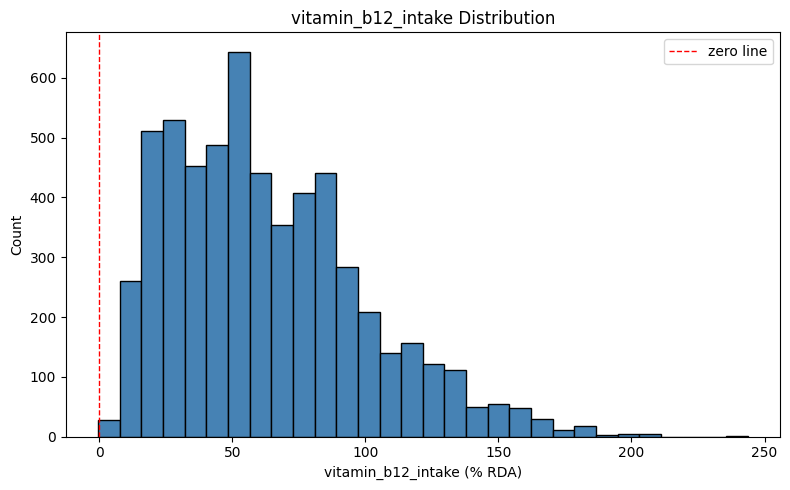

In [57]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['vitamin_b12_intake'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('vitamin_b12_intake Distribution')
plt.xlabel('vitamin_b12_intake (% RDA)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

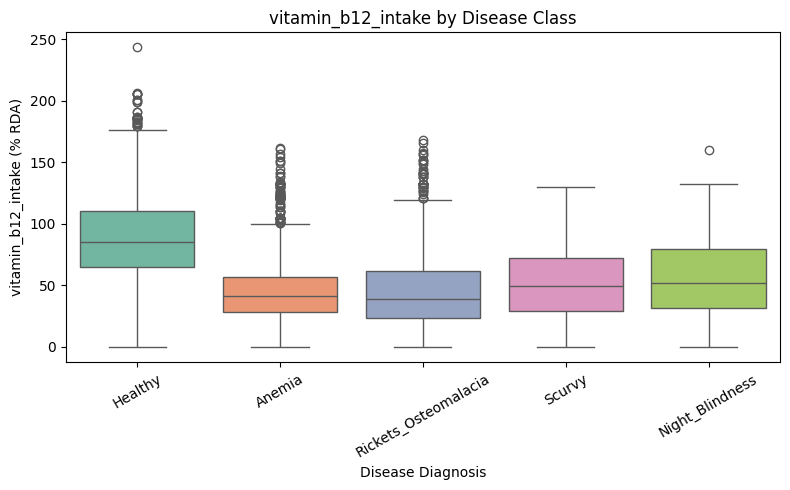

In [58]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='vitamin_b12_intake', palette='Set2')
plt.title('vitamin_b12_intake by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('vitamin_b12_intake (% RDA)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [59]:
# stats per class
print(df.groupby('disease_diagnosis')['vitamin_b12_intake'].describe().round(2))

                       count   mean    std   min    25%    50%     75%     max
disease_diagnosis                                                             
Anemia                1805.0  46.94  26.60 -0.37  28.10  41.20   57.10  161.80
Healthy               2121.0  89.91  33.55 -0.37  65.20  85.30  110.30  243.60
Night_Blindness        269.0  56.58  30.65 -0.37  31.88  52.22   79.40  160.20
Rickets_Osteomalacia  1429.0  46.82  29.80 -0.37  23.50  39.30   62.00  168.20
Scurvy                 176.0  52.58  28.76 -0.37  29.10  49.79   72.48  129.75


In [60]:
feature_6_insights = """

vitamin_b12_intake measures a patient's vitamin B12 consumption as a
percentage of the Recommended Dietary Allowance. 26 patients have negative
values which are biologically impossible and will be removed during data
preparation.

The distribution is right skewed with most patients consuming between 0 and
100 percent of the RDA. This suggests many patients in the dataset are not
meeting their daily vitamin B12 requirement.

The boxplot shows a very clear separation between Healthy patients and all
disease classes. Healthy patients have a median of 85.30 percent of RDA
while Anemia and Rickets_Osteomalacia both sit around 40 percent, roughly
half the intake of Healthy patients. Scurvy and Night_Blindness sit slightly
higher at around 50 percent but still well below Healthy.

This makes clinical sense as vitamin B12 deficiency is directly linked to
Anemia. The strong correlation of 0.76 between vitamin_b12_intake and
serum_vitamin_b12 seen in the correlation matrix further confirms this
relationship.

vitamin_b12_intake is selected as a feature for all modelling experiments
due to its strong signal for separating Healthy patients from disease classes.

"""

In [61]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_6_insights)

### C.8 Explore Feature of Interest `vitamin_a_intake`

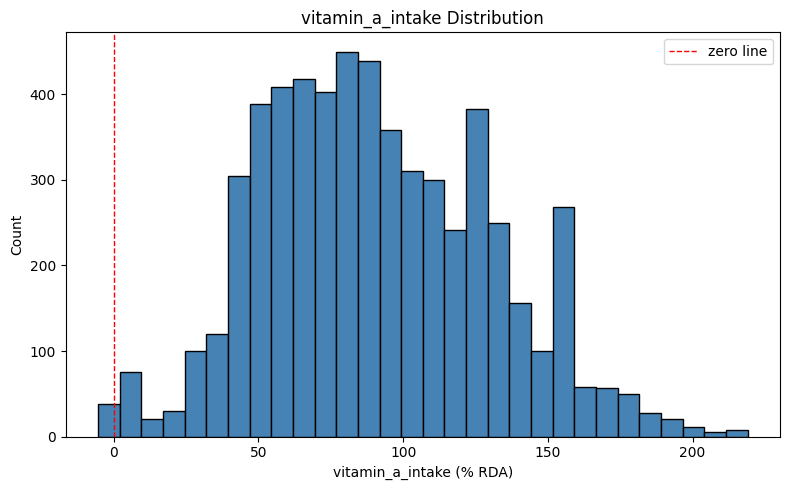

In [62]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['vitamin_a_intake'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('vitamin_a_intake Distribution')
plt.xlabel('vitamin_a_intake (% RDA)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

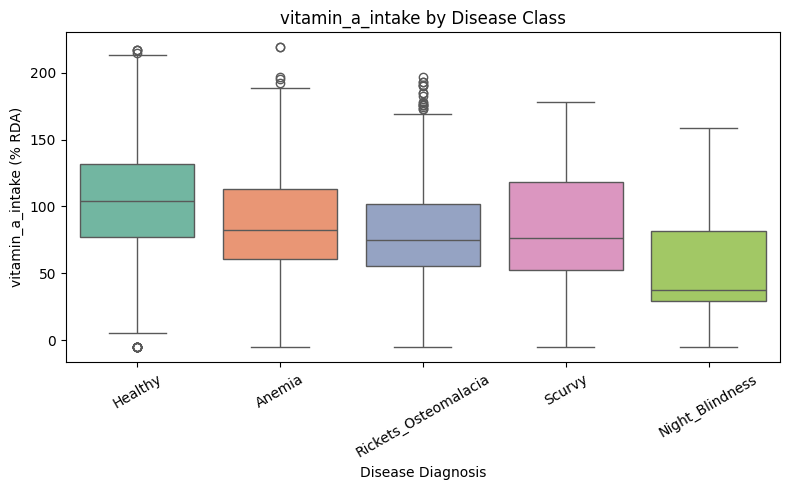

In [63]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='vitamin_a_intake', palette='Set2')
plt.title('vitamin_a_intake by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('vitamin_a_intake (% RDA)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [64]:
# stats per class
print(df.groupby('disease_diagnosis')['vitamin_a_intake'].describe().round(2))

                       count    mean    std   min   25%    50%     75%     max
disease_diagnosis                                                             
Anemia                1805.0   87.97  35.76 -5.41  60.8   82.7  112.80  219.00
Healthy               2121.0  105.16  38.72 -5.41  77.4  104.4  132.00  217.30
Night_Blindness        269.0   54.99  42.07 -5.41  29.4   37.5   81.58  159.03
Rickets_Osteomalacia  1429.0   80.57  35.32 -5.41  55.7   75.1  101.70  197.10
Scurvy                 176.0   83.82  41.13 -5.41  52.4   76.7  118.40  177.90


In [65]:
feature_7_insights = """

vitamin_a_intake measures a patient's vitamin A consumption as a percentage
of the Recommended Dietary Allowance. 38 patients have negative values which
are biologically impossible and will be removed during data preparation.

The distribution is roughly bell shaped with most patients consuming between
40 and 150 percent of the RDA.

The boxplot shows a very clear separation for Night_Blindness patients. The
Night_Blindness median is only 37.50 percent of RDA compared to 104.40 for
Healthy patients. This is the expected clinical relationship as vitamin A
deficiency is the direct cause of Night Blindness. The Night_Blindness box
also shows high variability with a wide spread from near 0 to around 160
percent.

All other disease classes, Anemia, Rickets and Scurvy, cluster between 75
and 88 percent and overlap considerably with each other. This feature is
most useful for identifying Night_Blindness patients specifically.

vitamin_a_intake is selected as a feature for all modelling experiments due
to its strong signal for Night_Blindness detection.

"""

In [66]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_7_insights)

### C.9 Explore Feature of Interest `iron_intake`

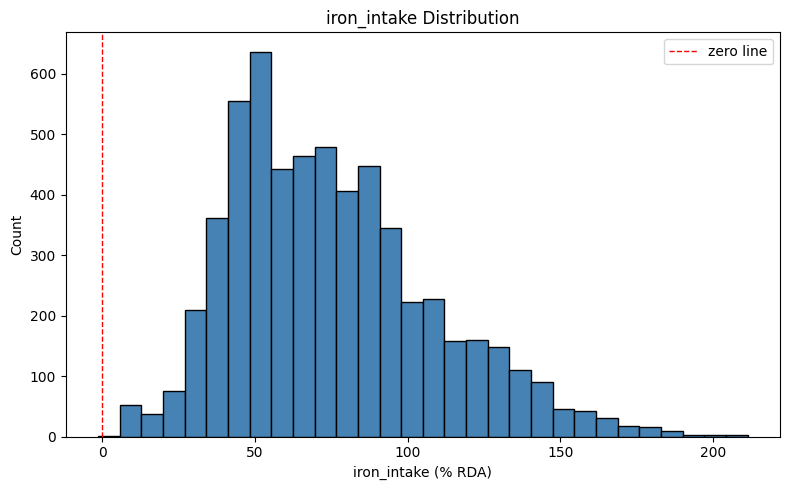

In [67]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['iron_intake'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('iron_intake Distribution')
plt.xlabel('iron_intake (% RDA)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

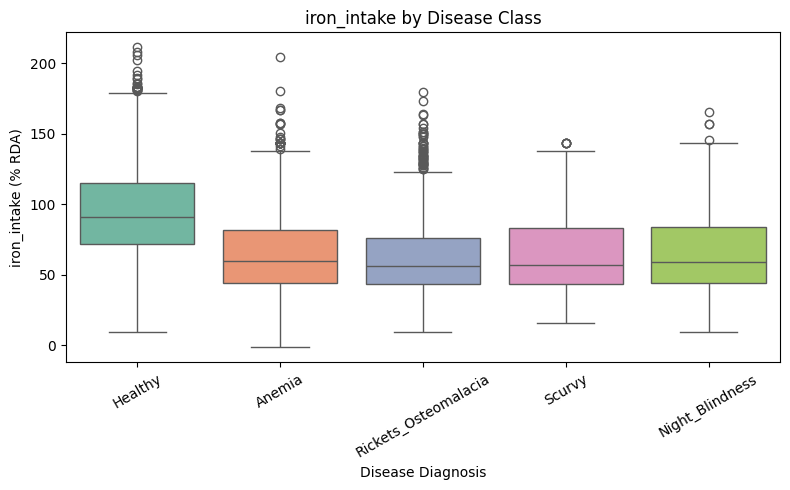

In [68]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='iron_intake', palette='Set2')
plt.title('iron_intake by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('iron_intake (% RDA)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [69]:
# stats per class
print(df.groupby('disease_diagnosis')['iron_intake'].describe().round(2))

                       count   mean    std    min    25%    50%     75%  \
disease_diagnosis                                                         
Anemia                1805.0  64.76  27.89  -1.41  44.30  59.70   82.20   
Healthy               2121.0  95.10  32.11   9.18  71.60  90.80  115.20   
Night_Blindness        269.0  66.68  30.79   9.18  44.30  59.00   84.23   
Rickets_Osteomalacia  1429.0  62.27  27.15   9.18  43.30  56.20   76.00   
Scurvy                 176.0  65.61  28.34  15.60  43.65  56.75   83.41   

                         max  
disease_diagnosis             
Anemia                204.20  
Healthy               211.40  
Night_Blindness       165.80  
Rickets_Osteomalacia  179.70  
Scurvy                143.83  


In [70]:
feature_8_insights = """

iron_intake measures a patient's iron consumption as a percentage of the
Recommended Dietary Allowance. Only 1 patient has a negative value which
will be removed during data preparation.

The distribution is right skewed with most patients consuming between 20
and 120 percent of the RDA.

The boxplot shows a clear separation between Healthy patients and all disease
classes. Healthy patients have a median of 90.80 percent of RDA while all
four disease classes cluster closely together between 56 and 60 percent.
Unlike vitamin_a_intake and vitamin_c_intake which each identify a specific
disease, iron_intake separates Healthy from sick rather than distinguishing
between individual diseases.

This makes clinical sense as iron deficiency contributes to multiple
conditions including Anemia. The fact that all disease classes show similarly
low iron intake suggests iron deficiency may be a general indicator of poor
nutritional status rather than a specific marker for any single disease.

iron_intake is selected as a feature for modelling experiments as it provides
a useful signal for separating Healthy patients from all disease classes.

"""

In [71]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_8_insights)

### C.10 Explore Feature of Interest `folate_intake`

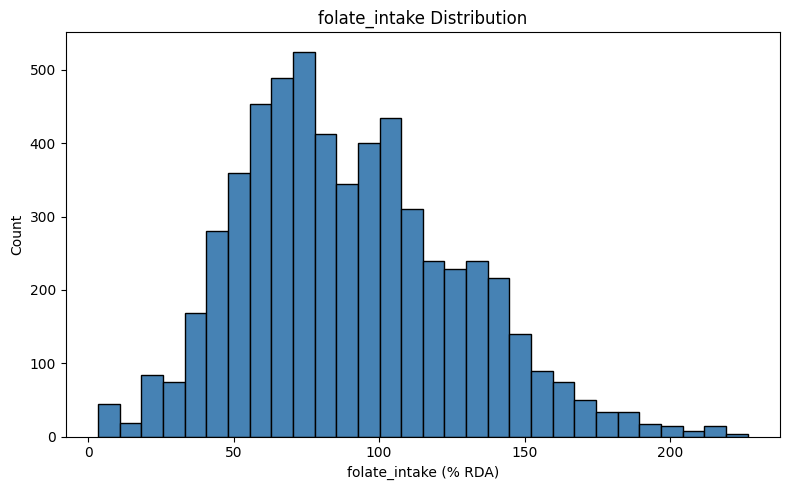

In [72]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['folate_intake'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('folate_intake Distribution')
plt.xlabel('folate_intake (% RDA)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

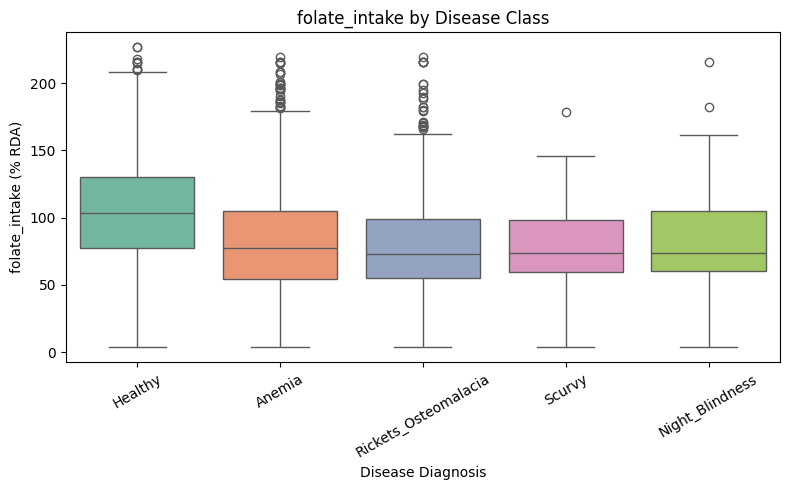

In [73]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='folate_intake', palette='Set2')
plt.title('folate_intake by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('folate_intake (% RDA)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [74]:
# stats per class
print(df.groupby('disease_diagnosis')['folate_intake'].describe().round(2))

                       count    mean    std   min    25%     50%     75%  \
disease_diagnosis                                                          
Anemia                1805.0   83.06  37.48  3.44  54.60   77.40  104.80   
Healthy               2121.0  105.21  35.57  3.44  77.60  103.20  130.00   
Night_Blindness        269.0   80.91  35.49  3.44  59.90   74.02  104.78   
Rickets_Osteomalacia  1429.0   79.00  33.78  3.44  55.20   73.20   98.80   
Scurvy                 176.0   77.03  28.59  3.44  59.88   74.02   97.83   

                        max  
disease_diagnosis            
Anemia                219.3  
Healthy               226.6  
Night_Blindness       215.6  
Rickets_Osteomalacia  219.1  
Scurvy                178.2  


In [75]:
feature_9_insights = """

folate_intake measures a patient's folate consumption as a percentage of the
Recommended Dietary Allowance. There are no negative values in this column.

The distribution is roughly bell shaped with most patients consuming between
40 and 150 percent of the RDA.

The boxplot shows that Healthy patients have a higher median of 103.20 percent
of RDA compared to all disease classes which cluster between 73 and 77 percent.
All four disease classes overlap heavily with each other meaning folate_intake
cannot distinguish between individual diseases. Like iron_intake it is more
useful as a general indicator of healthy vs unhealthy nutritional status.

The strong correlation of 0.75 between folate_intake and serum_folate seen in
the correlation matrix confirms that dietary folate intake is reflected in
blood folate levels as expected.

folate_intake is selected as a feature for modelling experiments as it
contributes to separating Healthy patients from disease classes.

"""

In [76]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_9_insights)

### C.11 Explore Feature of Interest `calcium_intake`

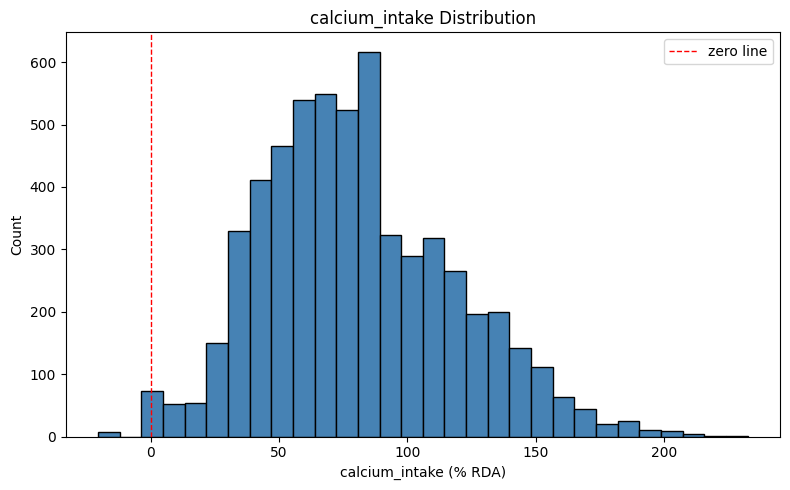

In [77]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['calcium_intake'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('calcium_intake Distribution')
plt.xlabel('calcium_intake (% RDA)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='zero line')
plt.legend()
plt.tight_layout()
plt.show()

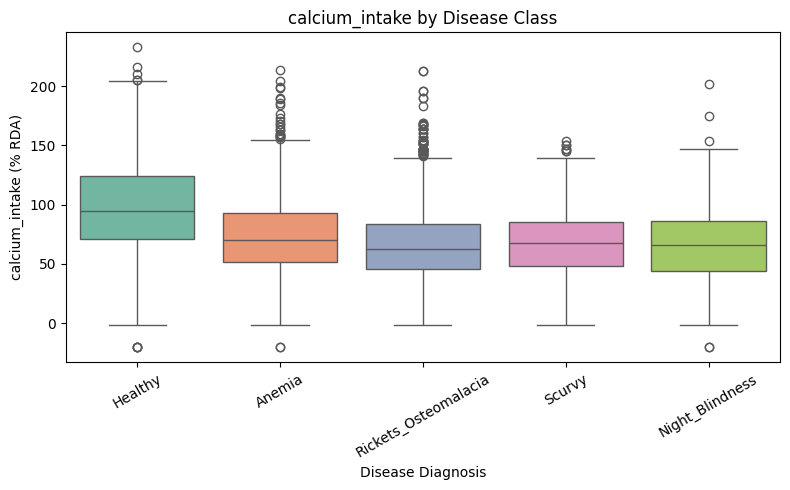

In [78]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='calcium_intake', palette='Set2')
plt.title('calcium_intake by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('calcium_intake (% RDA)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [79]:
# stats per class
print(df.groupby('disease_diagnosis')['calcium_intake'].describe().round(2))

                       count   mean    std    min    25%    50%     75%  \
disease_diagnosis                                                         
Anemia                1805.0  74.01  33.03 -20.59  51.30  70.10   92.80   
Healthy               2121.0  97.39  38.79 -20.59  71.10  94.50  124.40   
Night_Blindness        269.0  69.08  38.03 -20.59  44.00  66.00   85.70   
Rickets_Osteomalacia  1429.0  67.63  31.90  -2.09  45.40  62.20   83.70   
Scurvy                 176.0  68.52  32.13  -2.09  47.88  67.55   85.17   

                         max  
disease_diagnosis             
Anemia                213.50  
Healthy               232.70  
Night_Blindness       201.70  
Rickets_Osteomalacia  212.50  
Scurvy                153.69  


In [80]:
feature_10_insights = """

calcium_intake measures a patient's calcium consumption as a percentage of
the Recommended Dietary Allowance. 49 patients have negative values which
are biologically impossible and will be removed during data preparation.

The distribution is roughly bell shaped with most patients consuming between
30 and 150 percent of the RDA.

The boxplot shows that Healthy patients have a higher median of 94.50 percent
of RDA compared to all disease classes which cluster between 62 and 70
percent. All four disease classes overlap heavily with each other meaning
calcium_intake cannot distinguish between individual diseases on its own.

Calcium is closely linked to bone health so its lower intake in
Rickets_Osteomalacia patients at 62.20 median is clinically expected.
However since all other disease classes show similarly low calcium intake
the feature works better as a general health indicator rather than a
specific disease marker.

calcium_intake is selected as a feature for modelling experiments as it
contributes to separating Healthy patients from disease classes.

"""

In [81]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_10_insights)

### C.12 Explore Feature of Interest `symptoms_count`

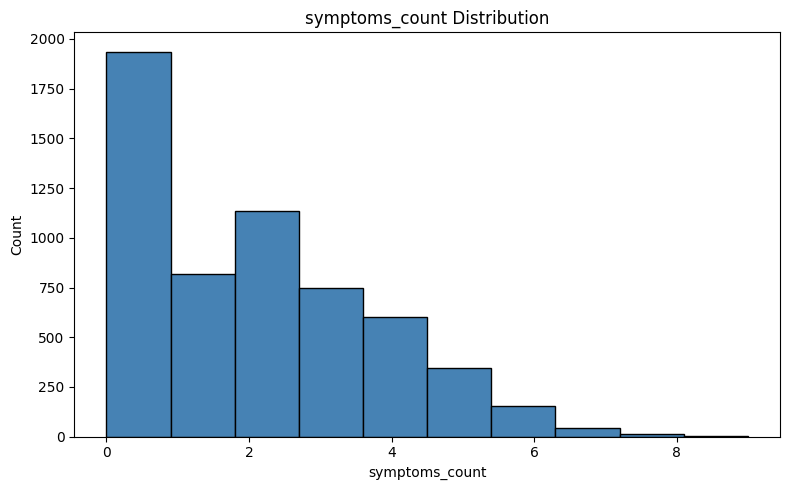

In [82]:
# distribution
plt.figure(figsize=(8, 5))
plt.hist(df['symptoms_count'].dropna(), bins=10,
         color='steelblue', edgecolor='black')
plt.title('symptoms_count Distribution')
plt.xlabel('symptoms_count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

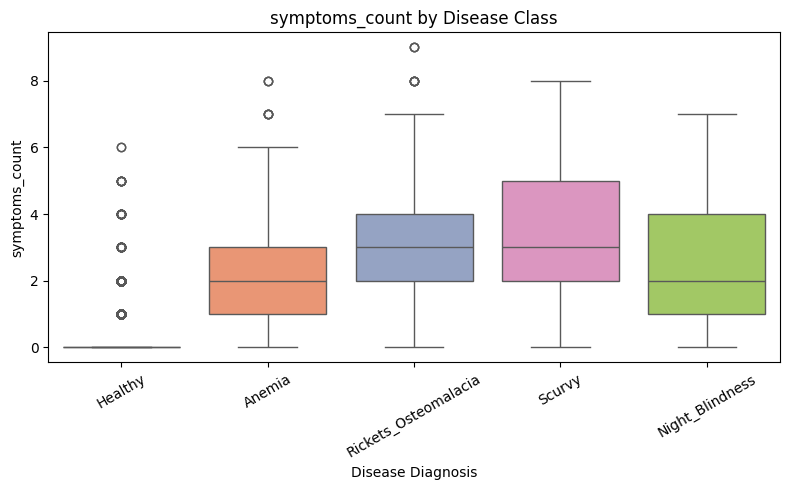

In [83]:
# boxplot by disease class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='disease_diagnosis', y='symptoms_count', palette='Set2')
plt.title('symptoms_count by Disease Class')
plt.xlabel('Disease Diagnosis')
plt.ylabel('symptoms_count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [84]:
# stats per class
print(df.groupby('disease_diagnosis')['symptoms_count'].describe().round(2))

                       count  mean   std  min  25%  50%  75%  max
disease_diagnosis                                                
Anemia                1805.0  2.33  1.43  0.0  1.0  2.0  3.0  8.0
Healthy               2121.0  0.36  0.83  0.0  0.0  0.0  0.0  6.0
Night_Blindness        269.0  2.59  1.86  0.0  1.0  2.0  4.0  7.0
Rickets_Osteomalacia  1429.0  3.23  1.64  0.0  2.0  3.0  4.0  9.0
Scurvy                 176.0  3.12  2.08  0.0  2.0  3.0  5.0  8.0


In [85]:
feature_11_insights = """

symptoms_count is the total number of symptoms a patient presents with out
of the 8 possible symptom columns in the dataset. There are no missing or
negative values in this column.

The distribution is heavily right skewed with a large spike at 0 representing
patients with no symptoms. This corresponds directly to the Healthy class
which makes up 36.6 percent of the dataset.

The boxplot shows one of the clearest separations across all features.
Healthy patients have a median of 0 symptoms while all disease classes sit
noticeably higher. Rickets_Osteomalacia and Scurvy both have a median of 3
symptoms, Anemia and Night_Blindness have a median of 2. This feature alone
can reliably distinguish Healthy patients from diseased patients.

The negative correlations with vitamin intake features seen in the correlation
matrix, as strong as -0.52 with vitamin_b12_intake, confirm that lower
vitamin intake is associated with a higher symptom count as expected
clinically.

symptoms_count is selected as a feature for all modelling experiments as it
is one of the strongest predictors of disease presence in the dataset.

"""

In [86]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_11_insights)

### C.13 Explore Feature of Interest `diet_type`

In [87]:
# value counts
print(df['diet_type'].value_counts(dropna=False))

diet_type
Vegan          1489
Pescatarian    1406
Omnivore       1389
Vegetarian     1343
NaN             129
Unknown          44
Name: count, dtype: int64


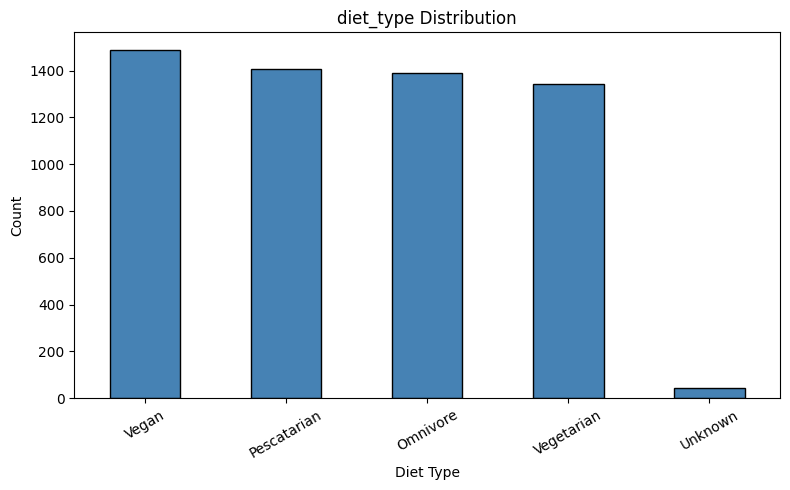

In [88]:
# bar chart of diet_type distribution
plt.figure(figsize=(8, 5))
df['diet_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('diet_type Distribution')
plt.xlabel('Diet Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

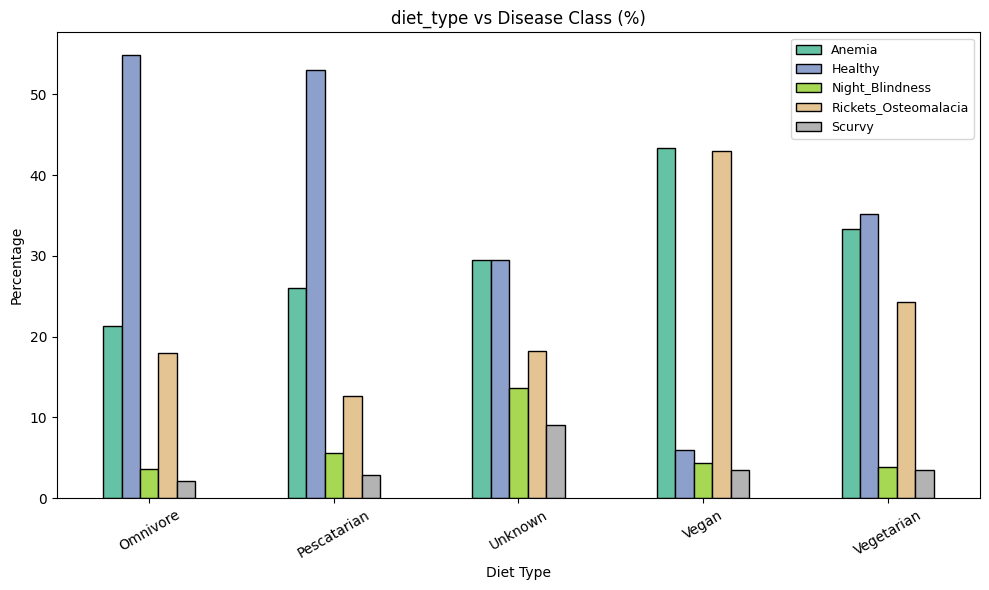

In [89]:
# crosstab vs disease class
crosstab = pd.crosstab(df['diet_type'], df['disease_diagnosis'], normalize='index') * 100

plt.figure(figsize=(10, 6))
crosstab.plot(kind='bar', colormap='Set2', edgecolor='black', figsize=(10, 6))
plt.title('diet_type vs Disease Class (%)')
plt.xlabel('Diet Type')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [90]:
# raw counts
print(pd.crosstab(df['diet_type'], df['disease_diagnosis']))

disease_diagnosis  Anemia  Healthy  Night_Blindness  Rickets_Osteomalacia  \
diet_type                                                                   
Omnivore              296      763               51                   250   
Pescatarian           365      746               78                   177   
Unknown                13       13                6                     8   
Vegan                 645       89               64                   640   
Vegetarian            448      472               51                   326   

disease_diagnosis  Scurvy  
diet_type                  
Omnivore               29  
Pescatarian            40  
Unknown                 4  
Vegan                  51  
Vegetarian             46  


In [91]:
# check quality of NaN rows for diet_type
nan_rows = df[df['diet_type'].isnull()]

print(f"=== NaN rows in diet_type ===")
print(f"Total: {len(nan_rows)}")
print()
print("Missing values in these rows:")
print(nan_rows[['diet_type', 'sun_exposure_type', 'income_band',
                'smoking_status', 'alcohol_consumption',
                'exercise_level', 'latitude_band']].isnull().sum())
print()
print("Disease distribution:")
print(nan_rows['disease_diagnosis'].value_counts())

=== NaN rows in diet_type ===
Total: 129

Missing values in these rows:
diet_type              129
sun_exposure_type       16
income_band             25
smoking_status          19
alcohol_consumption     52
exercise_level          33
latitude_band           19
dtype: int64

Disease distribution:
disease_diagnosis
Anemia                  38
Healthy                 38
Rickets_Osteomalacia    28
Night_Blindness         19
Scurvy                   6
Name: count, dtype: int64


In [92]:
feature_12_insights = """

diet_type records the dietary pattern of each patient across four main
categories: Omnivore, Pescatarian, Vegetarian and Vegan. There are 129 NaN
values and 44 Unknown entries.

Both the NaN and Unknown rows were investigated and found to have missing
values across multiple other columns including smoking_status,
alcohol_consumption and exercise_level. This indicates these are generally
low quality records rather than just a single missing field. For example
the 129 NaN rows have 52 missing alcohol_consumption values, 33 missing
exercise_level values and 25 missing income_band values. Given this, both
the NaN and Unknown rows will be dropped during data preparation.

The four main diet categories are fairly evenly distributed with Vegan
slightly highest at 1489 patients and Vegetarian lowest at 1343.

The crosstab reveals the strongest categorical signal in the entire dataset.
Omnivore patients are 55 percent Healthy and only 18 percent Rickets.
Pescatarian patients follow a similar pattern at 53 percent Healthy. Vegan
patients show a completely different profile with 43 percent Anemia and 43
percent Rickets and only 6 percent Healthy. Vegetarian patients sit between
the two extremes at 35 percent Healthy and 24 percent Rickets.

This pattern makes complete clinical sense. Vegan diets exclude all animal
products which are the primary dietary sources of vitamin B12, iron and
vitamin D. The absence of these nutrients directly explains the high rates
of Anemia and Rickets among Vegan patients in the dataset.

diet_type is selected as a feature for all modelling experiments as it is
the strongest categorical predictor of disease diagnosis.

"""

In [93]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_12_insights)

### C.14 Explore Feature of Interest `sun_exposure_type`

In [94]:
# value counts
print(df['sun_exposure_type'].value_counts(dropna=False))

sun_exposure_type
Moderate    1895
High        1820
Low         1789
Unknown      179
NaN          117
Name: count, dtype: int64


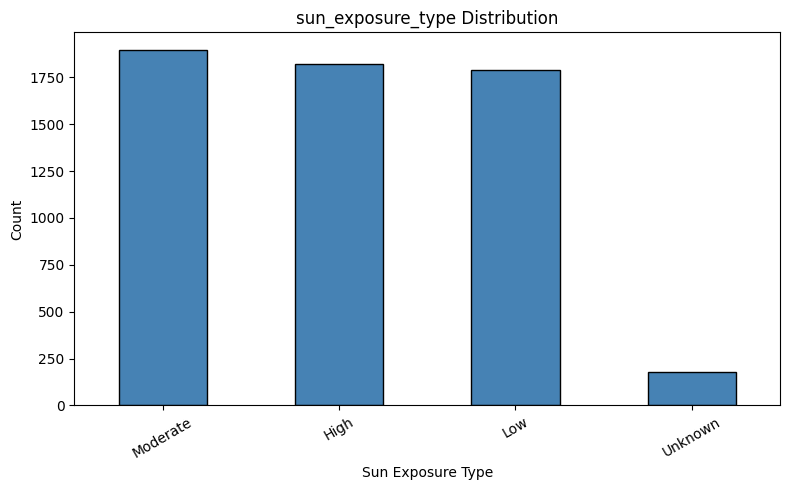

In [95]:
# bar chart
plt.figure(figsize=(8, 5))
df['sun_exposure_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('sun_exposure_type Distribution')
plt.xlabel('Sun Exposure Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

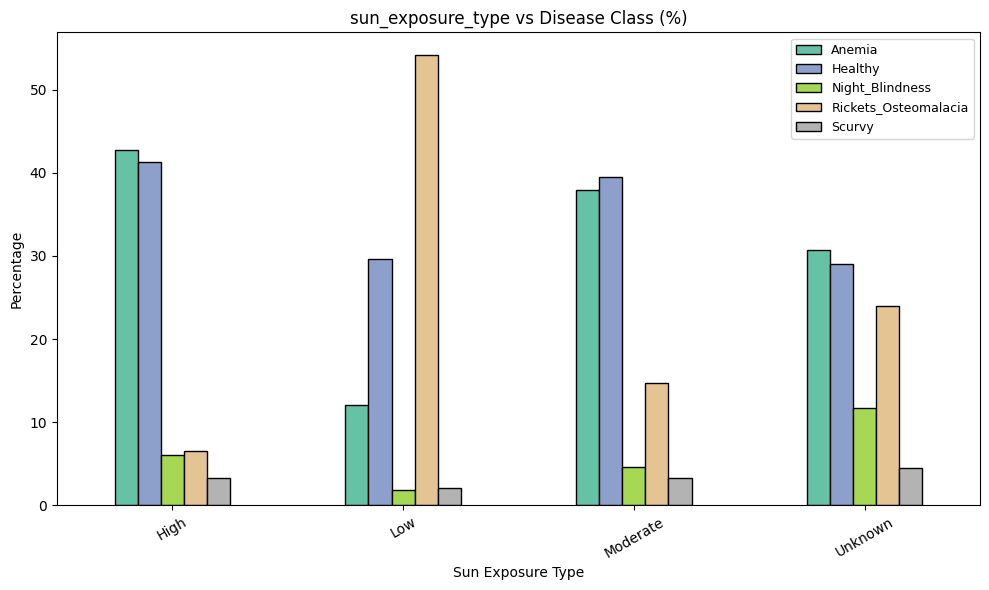

In [96]:
# crosstab vs disease class
crosstab = pd.crosstab(df['sun_exposure_type'], df['disease_diagnosis'], normalize='index') * 100

crosstab.plot(kind='bar', colormap='Set2', edgecolor='black', figsize=(10, 6))
plt.title('sun_exposure_type vs Disease Class (%)')
plt.xlabel('Sun Exposure Type')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [97]:
# raw counts
print(pd.crosstab(df['sun_exposure_type'], df['disease_diagnosis']))

disease_diagnosis  Anemia  Healthy  Night_Blindness  Rickets_Osteomalacia  \
sun_exposure_type                                                           
High                  777      752              111                   120   
Low                   217      531               34                   969   
Moderate              718      749               87                   278   
Unknown                55       52               21                    43   

disease_diagnosis  Scurvy  
sun_exposure_type          
High                   60  
Low                    38  
Moderate               63  
Unknown                 8  


In [98]:
# check quality of NaN rows for sun_exposure_type
nan_rows = df[df['sun_exposure_type'].isnull()]

print(f"=== NaN rows in sun_exposure_type ===")
print(f"Total: {len(nan_rows)}")
print()
print("Missing values in these rows:")
print(nan_rows[['diet_type', 'sun_exposure_type', 'income_band',
                'smoking_status', 'alcohol_consumption',
                'exercise_level', 'latitude_band']].isnull().sum())
print()
print("Disease distribution:")
print(nan_rows['disease_diagnosis'].value_counts())

=== NaN rows in sun_exposure_type ===
Total: 117

Missing values in these rows:
diet_type               16
sun_exposure_type      117
income_band             18
smoking_status          24
alcohol_consumption     43
exercise_level          26
latitude_band           20
dtype: int64

Disease distribution:
disease_diagnosis
Anemia                  38
Healthy                 37
Rickets_Osteomalacia    19
Night_Blindness         16
Scurvy                   7
Name: count, dtype: int64


In [99]:
feature_13_insights = """

sun_exposure_type records the level of sun exposure for each patient across
three categories: Low, Moderate and High. There are 117 NaN values and 179
Unknown entries.

Both the NaN and Unknown rows were investigated and found to have missing
values across multiple other columns. The 117 NaN rows have 43 missing
alcohol_consumption values, 26 missing exercise_level values and 18 missing
income_band values. The 179 Unknown rows similarly have missing values across
smoking_status, alcohol_consumption and exercise_level. These are low quality
records and both NaN and Unknown rows will be dropped during data preparation.

The three main categories are fairly evenly distributed with Moderate
slightly highest at 1895 patients, High at 1820 and Low at 1789.

The crosstab shows a very strong signal particularly for Rickets_Osteomalacia.
Patients with Low sun exposure have 54 percent Rickets compared to only 7
percent for High sun exposure patients. This makes complete clinical sense
as sunlight is the primary trigger for vitamin D synthesis in the skin.
Patients who get little sun exposure produce less vitamin D which directly
leads to Rickets and Osteomalacia.

High and Moderate sun exposure patients show much higher proportions of
Healthy and Anemia which aligns with sufficient vitamin D levels reducing
the risk of bone diseases.

sun_exposure_type is selected as a feature for all modelling experiments
as it is the second strongest categorical predictor after diet_type and
has a direct clinical link to Rickets_Osteomalacia diagnosis.

"""

In [100]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_13_insights)

### C.15 Explore Feature of Interest `income_band`

In [101]:
# value counts
print(df['income_band'].value_counts(dropna=False))

income_band
High       1877
Low        1846
Middle     1728
Unknown     191
NaN         158
Name: count, dtype: int64


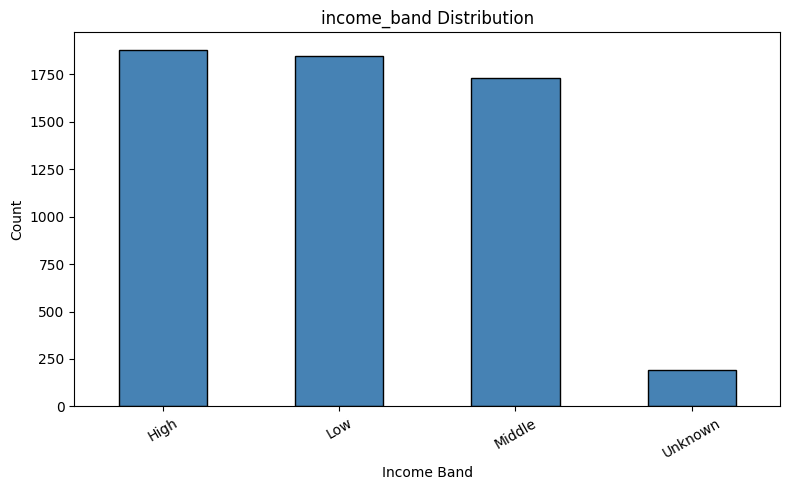

In [102]:
# bar chart
plt.figure(figsize=(8, 5))
df['income_band'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('income_band Distribution')
plt.xlabel('Income Band')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

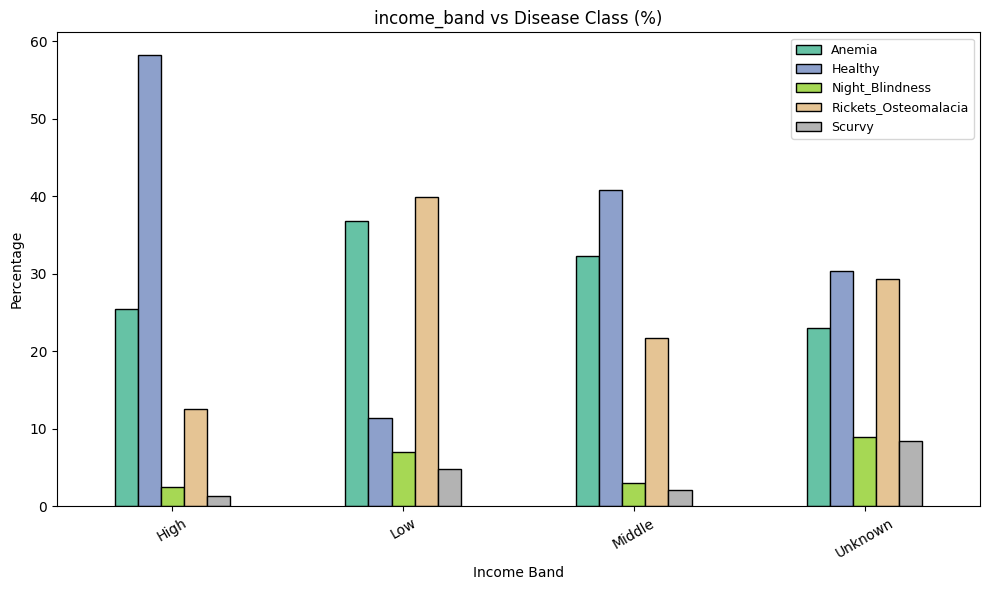

In [103]:
# crosstab vs disease class
crosstab = pd.crosstab(df['income_band'], df['disease_diagnosis'], normalize='index') * 100

crosstab.plot(kind='bar', colormap='Set2', edgecolor='black', figsize=(10, 6))
plt.title('income_band vs Disease Class (%)')
plt.xlabel('Income Band')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [104]:
# raw counts
print(pd.crosstab(df['income_band'], df['disease_diagnosis']))

disease_diagnosis  Anemia  Healthy  Night_Blindness  Rickets_Osteomalacia  \
income_band                                                                 
High                  477     1093               47                   235   
Low                   679      211              130                   737   
Middle                559      706               52                   375   
Unknown                44       58               17                    56   

disease_diagnosis  Scurvy  
income_band                
High                   25  
Low                    89  
Middle                 36  
Unknown                16  


In [105]:
# check quality of NaN rows for income_band
nan_rows = df[df['income_band'].isnull()]

print(f"=== NaN rows in income_band ===")
print(f"Total: {len(nan_rows)}")
print()
print("Missing values in these rows:")
print(nan_rows[['diet_type', 'sun_exposure_type', 'income_band',
                'smoking_status', 'alcohol_consumption',
                'exercise_level', 'latitude_band']].isnull().sum())
print()
print("Disease distribution:")
print(nan_rows['disease_diagnosis'].value_counts())

=== NaN rows in income_band ===
Total: 158

Missing values in these rows:
diet_type               25
sun_exposure_type       18
income_band            158
smoking_status          25
alcohol_consumption     73
exercise_level          31
latitude_band           22
dtype: int64

Disease distribution:
disease_diagnosis
Healthy                 53
Anemia                  46
Rickets_Osteomalacia    26
Night_Blindness         23
Scurvy                  10
Name: count, dtype: int64


In [106]:
# check quality of Unknown rows for income_band
unknown_rows = df[df['income_band'] == 'Unknown']

print(f"=== Unknown rows in income_band ===")
print(f"Total: {len(unknown_rows)}")
print()
print("Missing values in these rows:")
print(unknown_rows[['diet_type', 'sun_exposure_type', 'income_band',
                     'smoking_status', 'alcohol_consumption',
                     'exercise_level', 'latitude_band']].isnull().sum())
print()
print("Disease distribution:")
print(unknown_rows['disease_diagnosis'].value_counts())

=== Unknown rows in income_band ===
Total: 191

Missing values in these rows:
diet_type              22
sun_exposure_type      17
income_band             0
smoking_status         31
alcohol_consumption    78
exercise_level         35
latitude_band          34
dtype: int64

Disease distribution:
disease_diagnosis
Healthy                 58
Rickets_Osteomalacia    56
Anemia                  44
Night_Blindness         17
Scurvy                  16
Name: count, dtype: int64


In [107]:
feature_14_insights = """

income_band records the income level of each patient across three categories:
High, Low and Middle. There are 158 NaN values and 191 Unknown entries.

Both the NaN and Unknown rows were investigated and found to have missing
values across multiple other columns. The 158 NaN rows have 73 missing
alcohol_consumption values, 31 missing exercise_level values and 25 missing
diet_type values. The 191 Unknown rows have 78 missing alcohol_consumption
values, 35 missing exercise_level values and 31 missing smoking_status values.
These are low quality records and both NaN and Unknown rows will be dropped
during data preparation.

The three main categories are fairly evenly distributed with High slightly
highest at 1877 patients and Middle lowest at 1728.

The crosstab shows a strong signal across income levels. High income patients
are 58 percent Healthy and only 13 percent Rickets. Low income patients show
a completely different profile with 40 percent Rickets, 37 percent Anemia and
only 11 percent Healthy. Middle income patients sit between the two at 41
percent Healthy and 22 percent Rickets.

This pattern makes clinical sense. Higher income is associated with better
access to nutritious food, healthcare and dietary supplements. Lower income
often means poorer diet quality and reduced access to healthcare which
directly contributes to higher rates of nutritional deficiencies.

income_band is selected as a feature for all modelling experiments as it
shows a strong relationship with disease diagnosis across all three income
levels.

"""

In [108]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_14_insights)

### C.16 Explore Feature of Interest `has_night_blindness`

In [109]:
# value counts
print(df['has_night_blindness'].value_counts())
print(f"Missing: {df['has_night_blindness'].isnull().sum()}")

has_night_blindness
0    5199
1     601
Name: count, dtype: int64
Missing: 0


<Figure size 800x500 with 0 Axes>

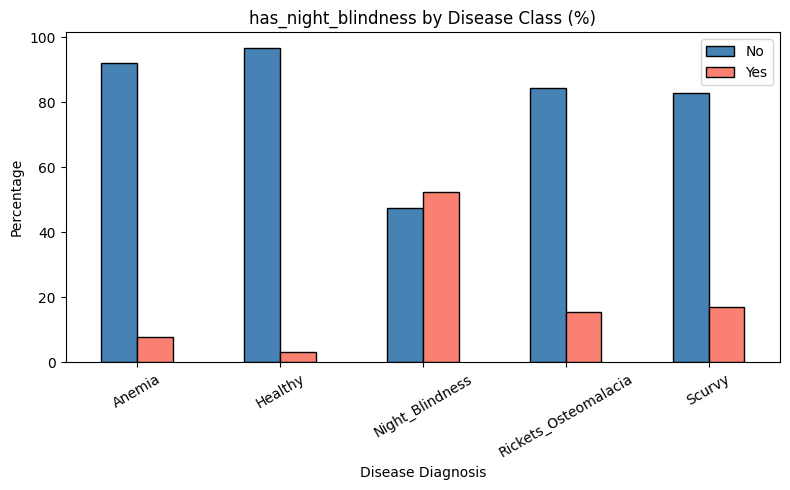

In [110]:
# bar chart by disease class
plt.figure(figsize=(8, 5))
crosstab = pd.crosstab(df['disease_diagnosis'], df['has_night_blindness'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('has_night_blindness by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [111]:
# stats per class
print(df.groupby('disease_diagnosis')['has_night_blindness'].mean().round(2))

disease_diagnosis
Anemia                  0.08
Healthy                 0.03
Night_Blindness         0.52
Rickets_Osteomalacia    0.15
Scurvy                  0.17
Name: has_night_blindness, dtype: float64


In [112]:
feature_15_insights = """

has_night_blindness is a binary column indicating whether a patient
experiences vision problems in low light conditions. 1 means the symptom
is present and 0 means it is absent. There are no missing values.

Out of 5800 patients, 601 (10.4%) have this symptom present. The remaining
5199 do not.

The bar chart shows a very clear signal. Night_Blindness patients have a
52 percent prevalence of this symptom compared to only 3 percent for Healthy
patients. This makes complete clinical sense as night blindness is the
defining symptom of vitamin A deficiency and directly names the disease
class. Anemia, Rickets and Scurvy all show low prevalence between 8 and 17
percent.

has_night_blindness is selected as a feature for all modelling experiments
as it is a strong and direct indicator of Night_Blindness diagnosis.

"""

In [113]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_15_insights)

### C.17 Explore Feature of Interest `has_fatigue`

In [114]:
# value counts
print(df['has_fatigue'].value_counts())
print(f"Missing: {df['has_fatigue'].isnull().sum()}")

has_fatigue
0    4234
1    1566
Name: count, dtype: int64
Missing: 0


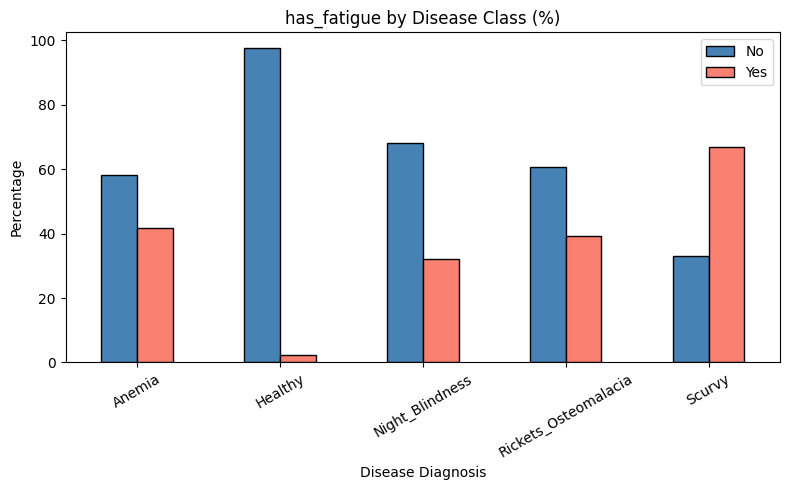

In [115]:
# bar chart by disease class
crosstab = pd.crosstab(df['disease_diagnosis'], df['has_fatigue'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('has_fatigue by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [116]:
# stats per class
print(df.groupby('disease_diagnosis')['has_fatigue'].mean().round(2))

disease_diagnosis
Anemia                  0.42
Healthy                 0.02
Night_Blindness         0.32
Rickets_Osteomalacia    0.39
Scurvy                  0.67
Name: has_fatigue, dtype: float64


In [117]:
feature_16_insights = """

has_fatigue is a binary column indicating whether a patient experiences
chronic tiredness. 1 means the symptom is present and 0 means it is absent.
There are no missing values.

Out of 5800 patients, 1566 (27%) have fatigue present making it the most
common symptom in the dataset.

The bar chart shows that Healthy patients have only 2 percent prevalence
while all disease classes are noticeably higher. Scurvy patients have the
highest fatigue rate at 67 percent followed by Anemia at 42 percent, Rickets
at 39 percent and Night_Blindness at 32 percent.

Unlike has_night_blindness which strongly points to one specific disease,
fatigue is present across multiple disease classes. This makes clinical sense
as fatigue is a general symptom of nutritional deficiency rather than a
marker for any single condition. Its main value is in separating Healthy
patients from diseased patients rather than distinguishing between diseases.

has_fatigue is selected as a feature for all modelling experiments as it
contributes to identifying diseased patients across all classes.

"""

In [118]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_16_insights)

### C.18 Explore Feature of Interest `has_bleeding_gums`

In [119]:
# value counts
print(df['has_bleeding_gums'].value_counts())
print(f"Missing: {df['has_bleeding_gums'].isnull().sum()}")

has_bleeding_gums
0    5556
1     244
Name: count, dtype: int64
Missing: 0


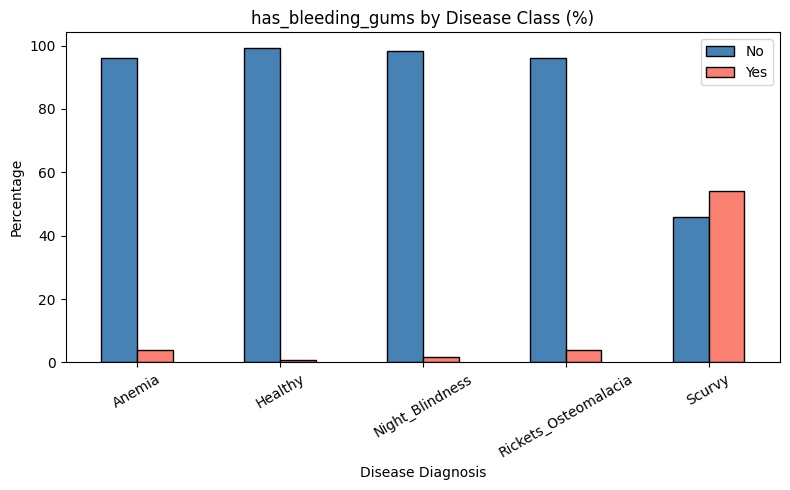

In [120]:
# bar chart by disease class
crosstab = pd.crosstab(df['disease_diagnosis'], df['has_bleeding_gums'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('has_bleeding_gums by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [121]:
# stats per class
print(df.groupby('disease_diagnosis')['has_bleeding_gums'].mean().round(2))

disease_diagnosis
Anemia                  0.04
Healthy                 0.01
Night_Blindness         0.02
Rickets_Osteomalacia    0.04
Scurvy                  0.54
Name: has_bleeding_gums, dtype: float64


In [122]:
feature_17_insights = """

has_bleeding_gums is a binary column indicating whether a patient experiences
gum inflammation or bleeding. 1 means the symptom is present and 0 means it
is absent. There are no missing values and only 244 patients (4.2%) have this
symptom present, making it one of the rarest symptoms in the dataset.

The bar chart shows the most specific signal of all symptom columns. Scurvy
patients have a 54 percent prevalence of bleeding gums while every other
class sits below 4 percent. Healthy patients have only 1 percent prevalence.

This makes complete clinical sense as bleeding gums is the textbook defining
symptom of Scurvy, which is caused by severe vitamin C deficiency. Vitamin C
is essential for collagen synthesis which maintains the integrity of gum
tissue. Without it gums become fragile and bleed easily.

has_bleeding_gums is one of the strongest and most specific predictors in
the dataset. It is selected as a feature for all modelling experiments as it
provides a near-direct indicator of Scurvy diagnosis.

"""

In [123]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_17_insights)

### C.19 Explore Feature of Interest `has_bone_pain`

In [124]:
# value counts
print(df['has_bone_pain'].value_counts())
print(f"Missing: {df['has_bone_pain'].isnull().sum()}")

has_bone_pain
0    4051
1    1749
Name: count, dtype: int64
Missing: 0


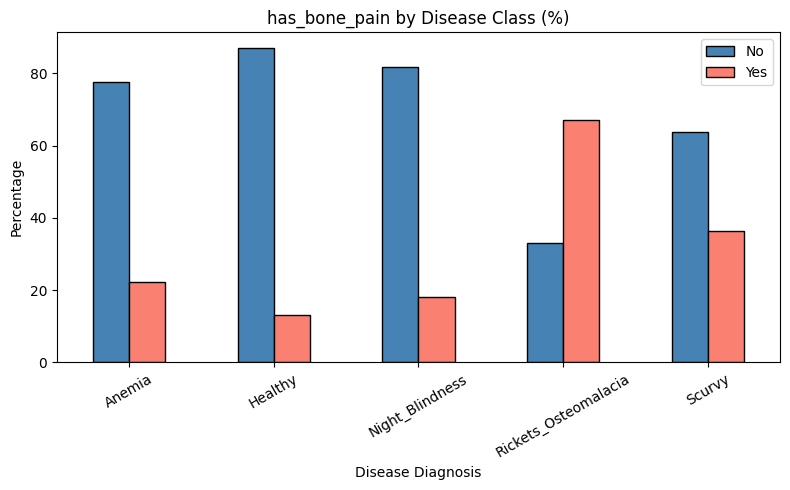

In [125]:
# bar chart by disease class
crosstab = pd.crosstab(df['disease_diagnosis'], df['has_bone_pain'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('has_bone_pain by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [126]:
# stats per class
print(df.groupby('disease_diagnosis')['has_bone_pain'].mean().round(2))

disease_diagnosis
Anemia                  0.22
Healthy                 0.13
Night_Blindness         0.18
Rickets_Osteomalacia    0.67
Scurvy                  0.36
Name: has_bone_pain, dtype: float64


In [127]:
feature_18_insights = """

has_bone_pain is a binary column indicating whether a patient experiences
skeletal discomfort. 1 means the symptom is present and 0 means it is
absent. There are no missing values and 1749 patients (30.2%) have this
symptom present.

The bar chart shows a very strong signal for Rickets_Osteomalacia.
Rickets patients have a 67 percent prevalence of bone pain compared to
only 13 percent for Healthy patients. Scurvy is second at 36 percent
followed by Anemia at 22 percent and Night_Blindness at 18 percent.

This makes complete clinical sense as Rickets and Osteomalacia are bone
diseases caused by vitamin D and calcium deficiency. Softening and weakening
of bones directly causes skeletal pain and discomfort. Similar to how
has_bleeding_gums points specifically to Scurvy, has_bone_pain is a strong
and relatively specific indicator of Rickets_Osteomalacia.

has_bone_pain is selected as a feature for all modelling experiments as it
provides a strong signal for Rickets_Osteomalacia diagnosis specifically.

"""

In [128]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_18_insights)

### C.20 Explore Feature of Interest `has_muscle_weakness`

In [129]:
# value counts
print(df['has_muscle_weakness'].value_counts())
print(f"Missing: {df['has_muscle_weakness'].isnull().sum()}")

has_muscle_weakness
0    4269
1    1531
Name: count, dtype: int64
Missing: 0


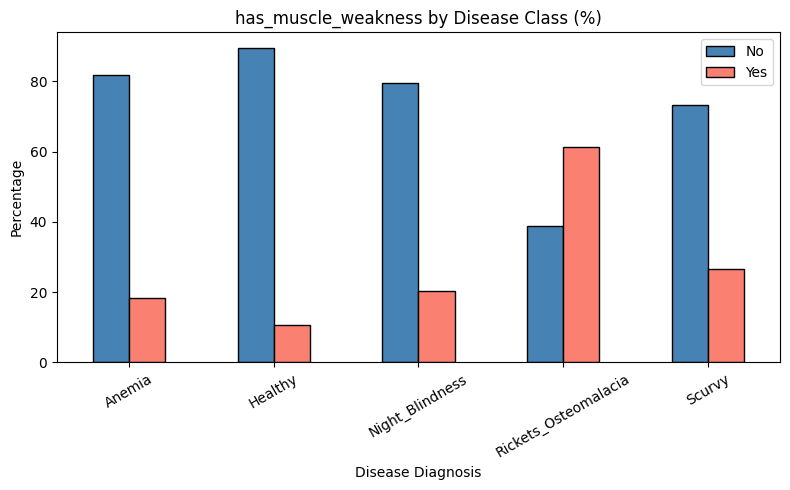

In [130]:
# bar chart by disease class
crosstab = pd.crosstab(df['disease_diagnosis'], df['has_muscle_weakness'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('has_muscle_weakness by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [131]:
# stats per class
print(df.groupby('disease_diagnosis')['has_muscle_weakness'].mean().round(2))

disease_diagnosis
Anemia                  0.18
Healthy                 0.11
Night_Blindness         0.20
Rickets_Osteomalacia    0.61
Scurvy                  0.27
Name: has_muscle_weakness, dtype: float64


In [132]:
feature_19_insights = """

has_muscle_weakness is a binary column indicating whether a patient
experiences reduced muscle strength. 1 means the symptom is present and
0 means it is absent. There are no missing values and 1531 patients (26.4%)
have this symptom present.

The bar chart shows a strong signal for Rickets_Osteomalacia. Rickets
patients have a 61 percent prevalence of muscle weakness compared to only
11 percent for Healthy patients. Scurvy is second at 27 percent followed
by Night_Blindness at 20 percent and Anemia at 18 percent.

This pattern closely mirrors has_bone_pain which is expected clinically.
Vitamin D and calcium deficiency affects both bone density and muscle
function simultaneously. Patients with Rickets therefore tend to present
with both bone pain and muscle weakness together.

has_muscle_weakness is selected as a feature for all modelling experiments
as it provides a strong and specific signal for Rickets_Osteomalacia
diagnosis alongside has_bone_pain.

"""

In [133]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_19_insights)

### C.21 Explore Feature of Interest `Peripheral neuropathy`

In [134]:
# value counts
print(df['Peripheral neuropathy'].value_counts())
print(f"Missing: {df['Peripheral neuropathy'].isnull().sum()}")

Peripheral neuropathy
0    3791
1    2009
Name: count, dtype: int64
Missing: 0


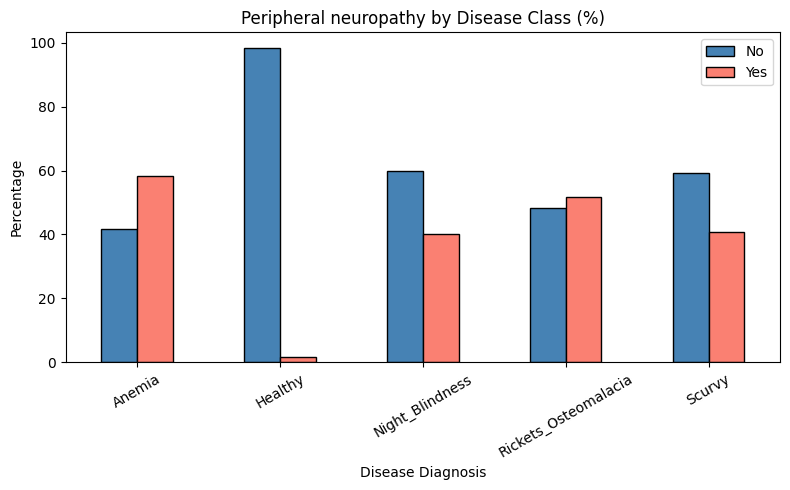

In [135]:
# bar chart by disease class
crosstab = pd.crosstab(df['disease_diagnosis'], df['Peripheral neuropathy'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('Peripheral neuropathy by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [136]:
# stats per class
print(df.groupby('disease_diagnosis')['Peripheral neuropathy'].mean().round(2))

disease_diagnosis
Anemia                  0.58
Healthy                 0.02
Night_Blindness         0.40
Rickets_Osteomalacia    0.52
Scurvy                  0.41
Name: Peripheral neuropathy, dtype: float64


In [137]:
feature_20_insights = """

Peripheral neuropathy is a binary column indicating whether a patient
experiences numbness or tingling sensations. 1 means the symptom is present
and 0 means it is absent. There are no missing values and 2009 patients
(34.6%) have this symptom present, making it the second most common symptom
in the dataset after has_fatigue.

The bar chart shows that Healthy patients have only 2 percent prevalence
while all disease classes are substantially higher. Anemia patients have
the highest prevalence at 58 percent followed by Rickets at 52 percent,
Scurvy at 41 percent and Night_Blindness at 40 percent.

Unlike has_bleeding_gums and has_night_blindness which point strongly to
specific diseases, peripheral neuropathy is spread fairly evenly across all
disease classes. This makes clinical sense as nerve damage from nutritional
deficiency can occur across multiple vitamin deficiency conditions. Its
main value is in separating Healthy patients from diseased patients.

Peripheral neuropathy is selected as a feature for all modelling experiments
as it is a strong general indicator of disease presence.

"""

In [138]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_20_insights)

### C.22 Explore Feature of Interest `has_memory_problems`

In [139]:
# value counts
print(df['has_memory_problems'].value_counts())
print(f"Missing: {df['has_memory_problems'].isnull().sum()}")

has_memory_problems
0    4036
1    1764
Name: count, dtype: int64
Missing: 0


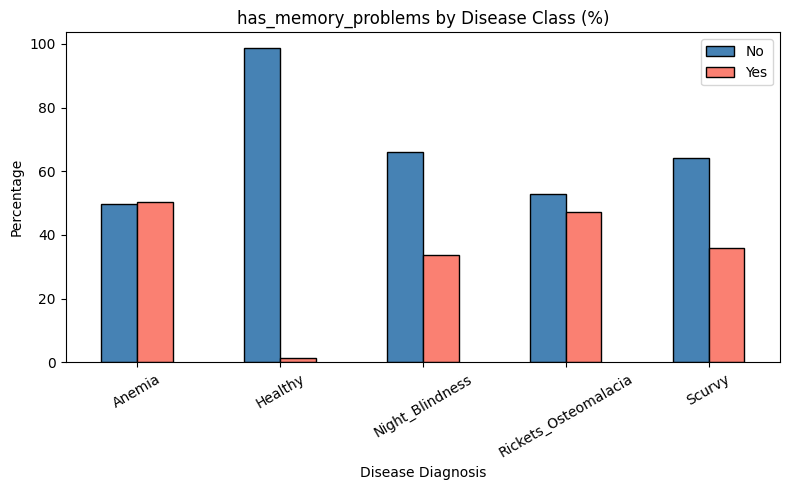

In [140]:
# bar chart by disease class
crosstab = pd.crosstab(df['disease_diagnosis'], df['has_memory_problems'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('has_memory_problems by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [141]:
# stats per class
print(df.groupby('disease_diagnosis')['has_memory_problems'].mean().round(2))

disease_diagnosis
Anemia                  0.50
Healthy                 0.01
Night_Blindness         0.34
Rickets_Osteomalacia    0.47
Scurvy                  0.36
Name: has_memory_problems, dtype: float64


In [142]:
feature_21_insights = """

has_memory_problems is a binary column indicating whether a patient
experiences cognitive issues. 1 means the symptom is present and 0 means
it is absent. There are no missing values and 1764 patients (30.4%) have
this symptom present.

The bar chart shows that Healthy patients have only 1 percent prevalence
while all disease classes are substantially higher. Anemia patients have
the highest prevalence at 50 percent followed by Rickets at 47 percent,
Scurvy at 36 percent and Night_Blindness at 34 percent.

Similar to Peripheral neuropathy, memory problems are spread across all
disease classes rather than pointing to a single condition. This makes
clinical sense as cognitive impairment can result from multiple nutritional
deficiencies including vitamin B12, folate and iron which affect brain
function and nerve health. Its main value is in separating Healthy patients
from diseased patients.

has_memory_problems is selected as a feature for all modelling experiments
as it is a strong general indicator of disease presence.

"""

In [143]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_21_insights)

### C.23 Explore Feature of Interest `has_pale_skin`

In [144]:
# value counts
print(df['has_pale_skin'].value_counts())
print(f"Missing: {df['has_pale_skin'].isnull().sum()}")

has_pale_skin
0    4844
1     956
Name: count, dtype: int64
Missing: 0


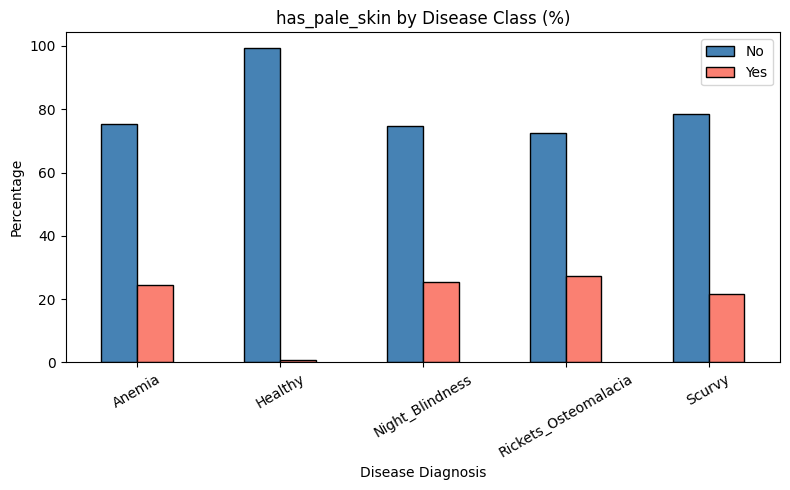

In [145]:
# bar chart by disease class
crosstab = pd.crosstab(df['disease_diagnosis'], df['has_pale_skin'], normalize='index') * 100
crosstab.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', figsize=(8, 5))
plt.title('has_pale_skin by Disease Class (%)')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

In [146]:
# stats per class
print(df.groupby('disease_diagnosis')['has_pale_skin'].mean().round(2))

disease_diagnosis
Anemia                  0.25
Healthy                 0.01
Night_Blindness         0.25
Rickets_Osteomalacia    0.27
Scurvy                  0.22
Name: has_pale_skin, dtype: float64


In [147]:
feature_22_insights = """

has_pale_skin is a binary column indicating whether a patient shows pallor
which is a known indicator of Anemia. 1 means the symptom is present and
0 means it is absent. There are no missing values and 956 patients (16.5%)
have this symptom present.

The bar chart shows that Healthy patients have only 1 percent prevalence
which clearly separates them from all disease classes. However all four
disease classes sit very closely together between 22 and 27 percent with
almost no difference between them. Rickets is slightly highest at 27
percent, Anemia and Night_Blindness both at 25 percent and Scurvy at 22
percent.

Despite being classically associated with Anemia, pale skin does not show
a stronger signal for Anemia than for other disease classes in this dataset.
This suggests pale skin is more of a general indicator of poor health rather
than a specific marker for any single disease.

has_pale_skin is selected as a feature for modelling experiments as it
still contributes to separating Healthy patients from all disease classes
even though it cannot distinguish between individual diseases.

"""

In [148]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_22_insights)